# Performance analysis of the different experiments in the manuscript

This notebook provides the analysis used to generate the different performance figures in the manuscript

In [56]:
%load_ext autoreload
%autoreload 2

import os

from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D


from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel

from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Defining setup
In our manuscript, we show performance of different models using Butina or Random splitting, and reporting MAE and $R^2$. The below code cell allows to identify the split files, and the netric to generate the analysis for
### This notebook shows the example for the Butina splitting and the $R^2$ metric


In [57]:
experiment_dir = 'repeated_5_5_CV'

butina = True
if butina:
    split_file = 'butina'
else:
    split_file = 'random'

all_metrics = ['MAE', 'RMSE', 'R2', 'r', 's_r']
metric = 'R2'

# making sure that R2 will be written with a superscript in the plots
metric_styling = {'R2': '$R^2$', 'MAE': 'MAE', 'RMSE': 'RMSE', 'r': 'Pearson R', 's_r': 'Spearman R'}

# adding an arrow to indicate which direction of the values correspond to a better performance
arrow_direction = {'R2': '↑', 'r': '↑', 's_r': '↑', 'MAE': '↓', 'RMSE': '↓'}

algorithm = 'random-forest' 

# Rename the domain-adaptation objectives (just a beatification measure!) 
da_objectives = ["No DA", "MLM", "CL", "MTR"]

# Set the colors to be used for each domain adaptation objective
da_colors = dict(zip(da_objectives, ["tab:blue", "tab:purple", "tab:orange", "tab:green"]))

da_colors_points = dict(zip(da_objectives, ["skyblue", "mediumpurple", "lightsalmon", "darkseagreen"]))


out_dir = f'analysis_figures/repeated_5_5_cv/{split_file}_splitting_analysis/{metric}/{algorithm}'
os.makedirs(out_dir, exist_ok=True)

## Loading our experiment results
* We have 4 variants of our pre-trained models:
    1. 0%: a randomly initialized model with no pre-training
    2. 30%: a model pre-trained with 30% of the GuacaMol dataset (i.e., ~400K molecules)
    3. 60%: a model pre-trained with 60% of the GuacaMol dataset (i.e., ~800K molecules)
    4. 100%: a model pre-trained with the full GuacaMol dataset (i.e., ~1.3M molecules)
* Our transformer models have been pre-trained using one of two pre-training objectives. We split our results into these two objective as we compare them to each other. These two objectives are: 
    1. Masked Language Modelling (MLM). This objective strictly learns structural information as provided by the SMILES string
    2. Multi-Task Regression (MTR). This objective teaches the model to predict a vector of ~210 physicochemical properties. Therefore, it's a chemically aware objective. 


In [58]:
# Collect the files from the two data sources as explained in the manuscript. Three datasets from ChEMBL provided by astrazeneca (Lipophilicit, Solubility, and HPPB), and 4 datasets from Fang et al (Solubility, Permeability, Intrinsic cleareance in humans and rats)
raw_predictions = pd.DataFrame()
predictions_metrics = pd.DataFrame()
for data_source in  ['astrazeneca', 'adme']:
    # Loading the raw results. Here, we have the prediction for each data point in each fold of the 5*5-folds. 
    experiments_raw_values = f'{experiment_dir}/{data_source}_{split_file}_results_all.csv'
    experiments_raw_df = pd.read_csv(experiments_raw_values, index_col=0)
    experiments_raw_df['da'] = pd.Categorical(experiments_raw_df['da'], categories=da_objectives, ordered=True)
    if data_source == 'astrazeneca':
        experiments_raw_df['dataset'] = experiments_raw_df['dataset'].replace('Solubility Log(ng/mL)', 'Solubility$_{Astrazeneca\_ChEMBL}$ Log(ng/mL)')
    else:
        experiments_raw_df['dataset'] = experiments_raw_df['dataset'].replace('Solubility Log(ug/mL)', 'Solubility$_{Fang\_et\_al}$ Log($\mu$g/mL)')
    raw_predictions = pd.concat([raw_predictions, experiments_raw_df])

    # Loading the evaluated file. Here, we have the different metrics for each fold of the 5*5-folds 
    experiments_metrics = f'{experiment_dir}/{data_source}_{split_file}_metrics_df.csv'
    experiments_metrics_df = pd.read_csv(experiments_metrics, index_col=0)
    if data_source == 'astrazeneca':
        experiments_metrics_df['dataset'] = experiments_metrics_df['dataset'].replace('Solubility Log(ng/mL)', 'Solubility$_{Astrazeneca\_ChEMBL}$ Log(ng/mL)')
    else:
        experiments_metrics_df['dataset'] = experiments_metrics_df['dataset'].replace('Solubility Log(ug/mL)', 'Solubility$_{Fang\_et\_al}$ Log($\mu$g/mL)')
    predictions_metrics = pd.concat([predictions_metrics, experiments_metrics_df])
    
    

datasets = predictions_metrics['dataset'].unique()
ds_sizes = sorted(predictions_metrics['train_size'].unique().tolist())

# Filtering the predictions by the specified metric and algorithm
ignored_metrics = [m for m in all_metrics if m != metric]
kept_cols = [col for col in experiments_metrics_df if col not in ignored_metrics]
predictions_metrics = predictions_metrics[kept_cols]
predictions_metrics['da'] = pd.Categorical(predictions_metrics['da'], categories=da_objectives, ordered=True)

raw_predictions_by_objective = {}
metrics_by_objective = {}
for pretrain_objective in ['mlm', 'mtr']:
    # Split the analysis by pre-training objective for both raw and evaluated predictions
    raw_objective = raw_predictions[raw_predictions['pretrain_objective'].isin([pretrain_objective, 'none'])]
    raw_objective.loc[:, 'pretrain_objective'] = raw_objective['pretrain_objective'].replace({'none': pretrain_objective})
    raw_predictions_by_objective[pretrain_objective] = raw_objective
    
    metric_objective = predictions_metrics[predictions_metrics['pretrain_objective'].isin([pretrain_objective, 'none'])]
    metric_objective.loc[:, 'pretrain_objective'] = metric_objective['pretrain_objective'].replace({'none': pretrain_objective})
    metrics_by_objective[pretrain_objective] = metric_objective

predictions_metrics = pd.concat(metrics_by_objective.values())

In [59]:
print(datasets)

['HPPB Log(% Bound)' 'Solubility$_{Astrazeneca\\_ChEMBL}$ Log(ng/mL)'
 'Lipophilicity LogD7.4' 'Solubility$_{Fang\\_et\\_al}$ Log($\\mu$g/mL)'
 'RLM Log(mL/min/kg)' 'Permeability Log(efflux ratio)'
 'HLM Log(mL/min/kg)']


In [60]:
# re-arrange the datasets for plotting
datasets = ['Lipophilicity LogD7.4', 'Permeability Log(efflux ratio)', 'Solubility$_{Fang\\_et\\_al}$ Log($\\mu$g/mL)', 'Solubility$_{Astrazeneca\\_ChEMBL}$ Log(ng/mL)', 'HLM Log(mL/min/kg)', 'RLM Log(mL/min/kg)', 'HPPB Log(% Bound)']

# Performance analysis

In the manuscript, we answered four research questions:
1. How does increasing pre-training dataset size affect performance?
2. How does domain adaptation with different objectives affect downstream performance?
3. What is the most efficient training approach without compromising performance?
4. How does domain adaptation compare to currently existing transformer and baseline models?

In the following, we will be showing the analysis used to answer these questions. 

## Pre-training dataset size
The below code plots the performance of the different models with different pre-training dataset sizes as distribution plots. Three figures are generated:
1. Performance for the models pre-trained with the MLM objective
2. Performance for the models pre-trained with MTR objective
3. Comparing the MLM vs MTR performance

### We mainly report the analysis for the MLM-pre-trained model. However, the below code cell shows it for the MTR-pre-trained model as well as a direct comparison of the two approaches using the different dataset setups.

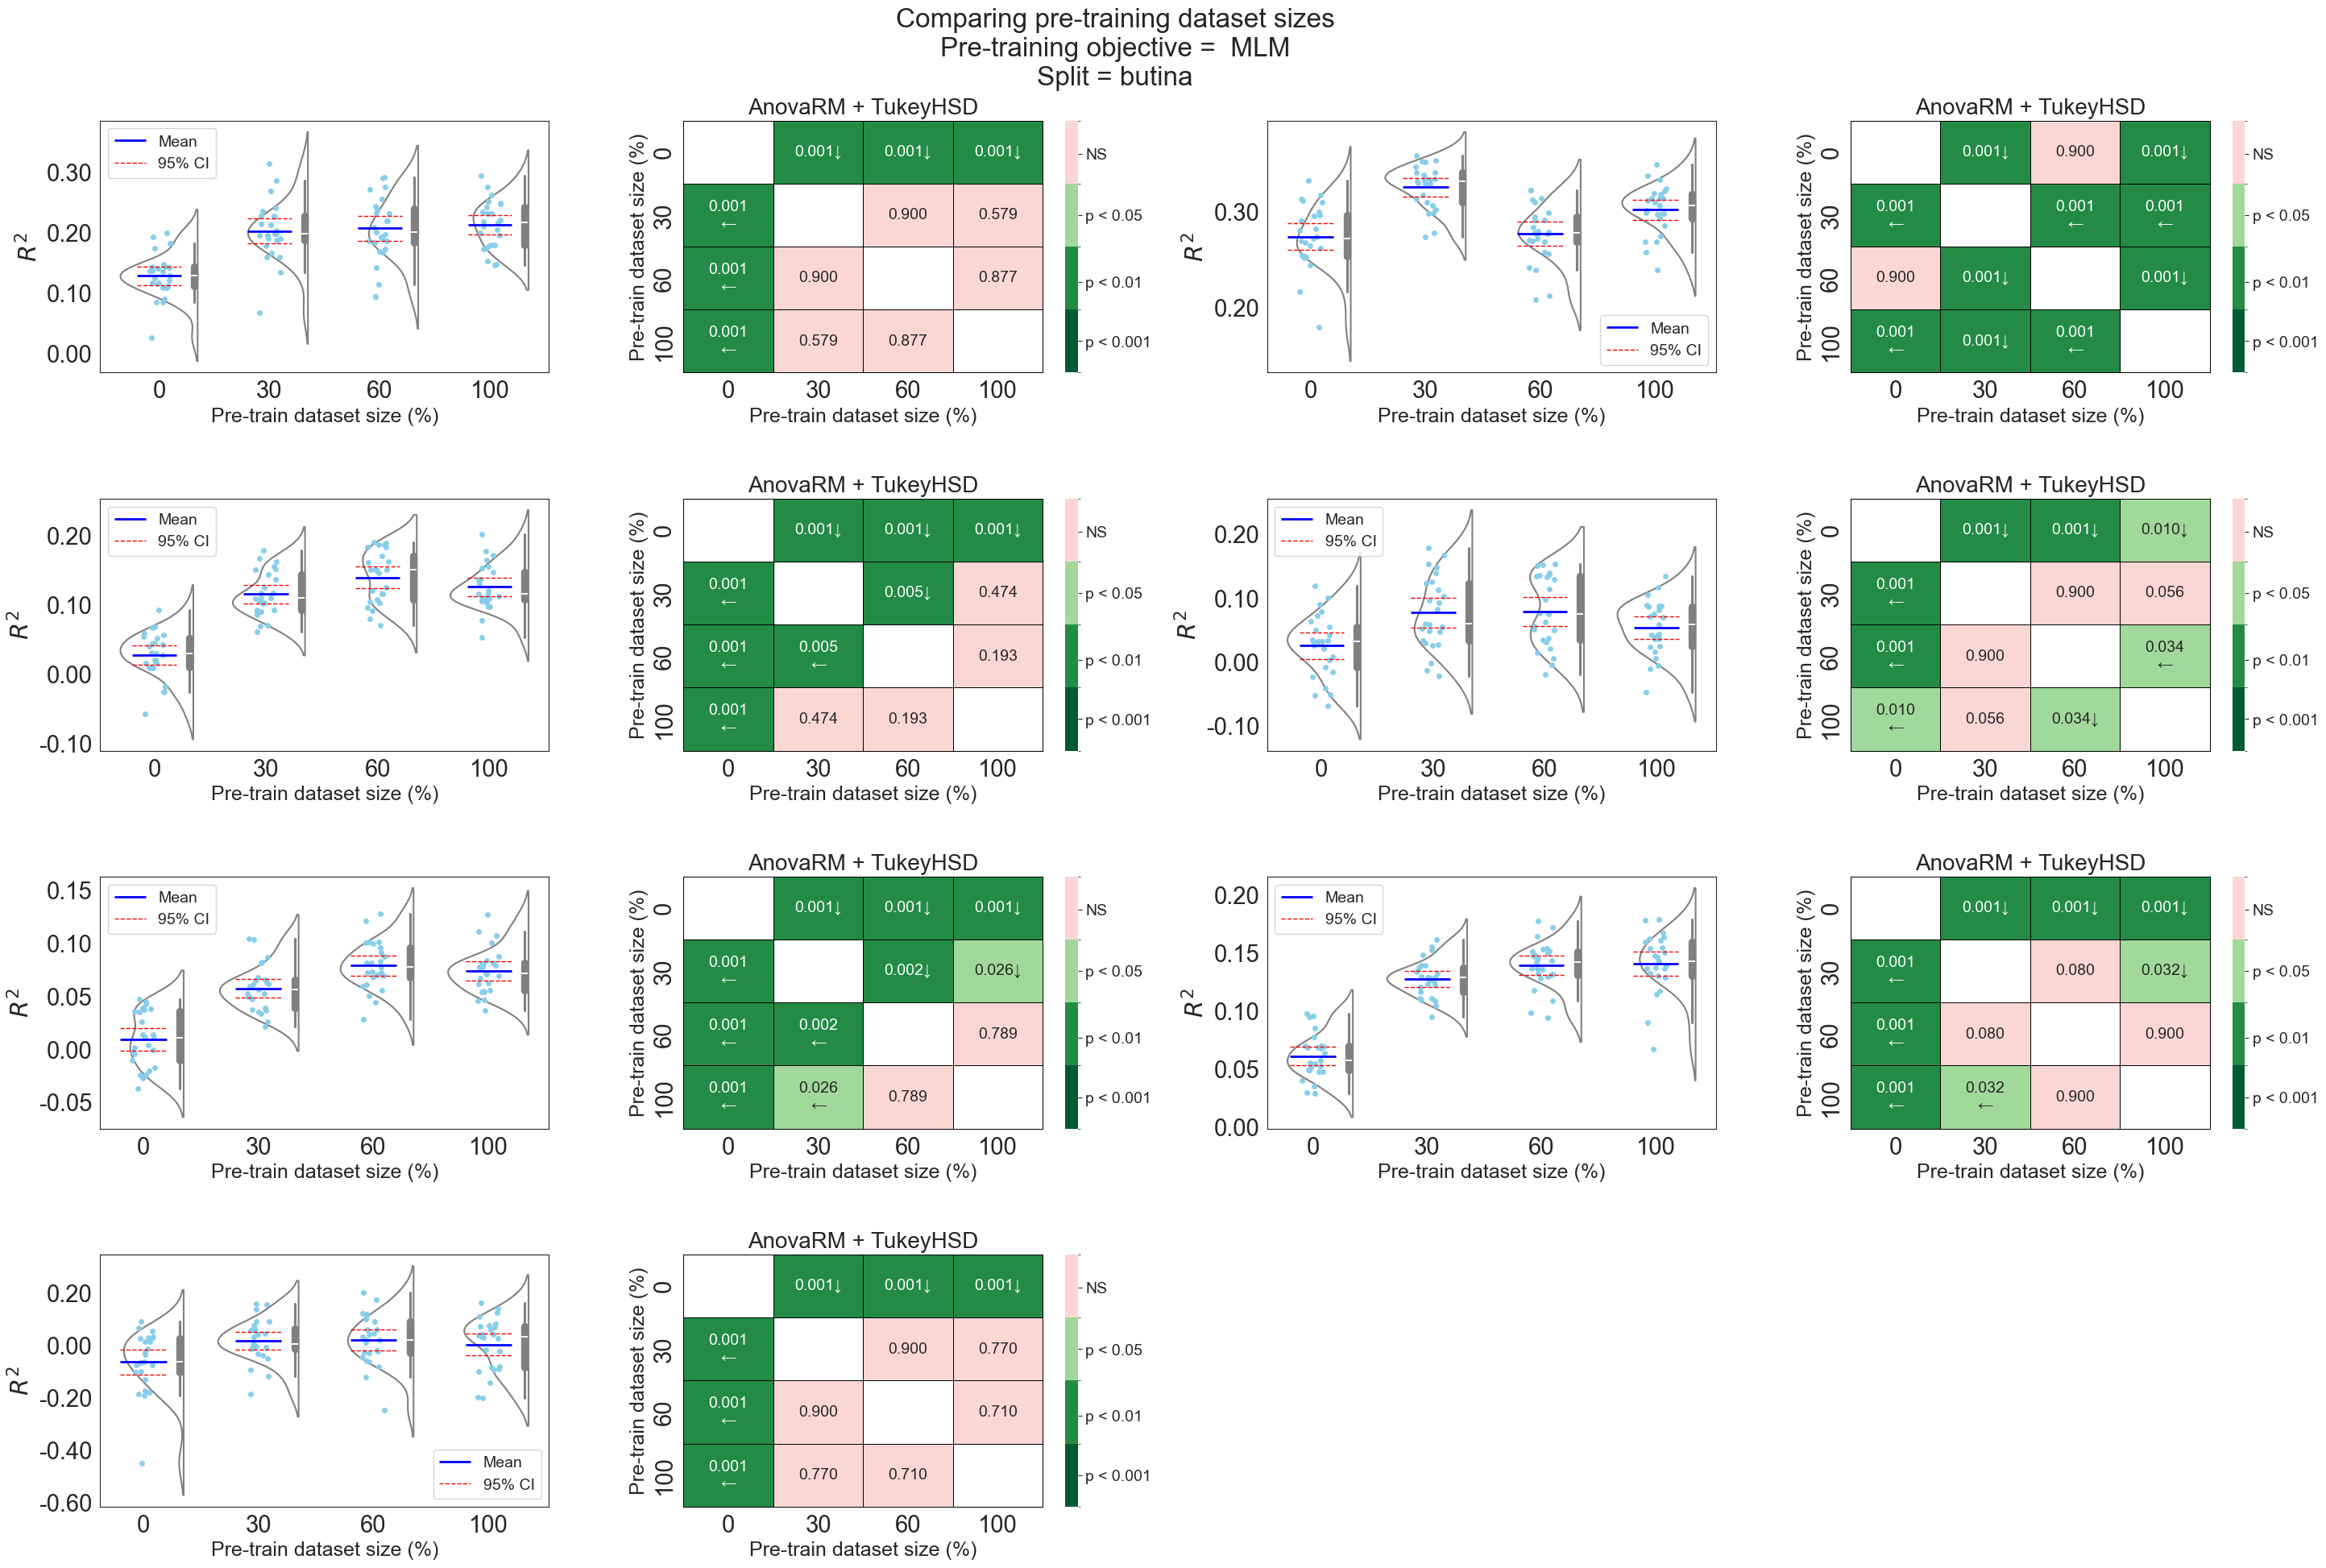

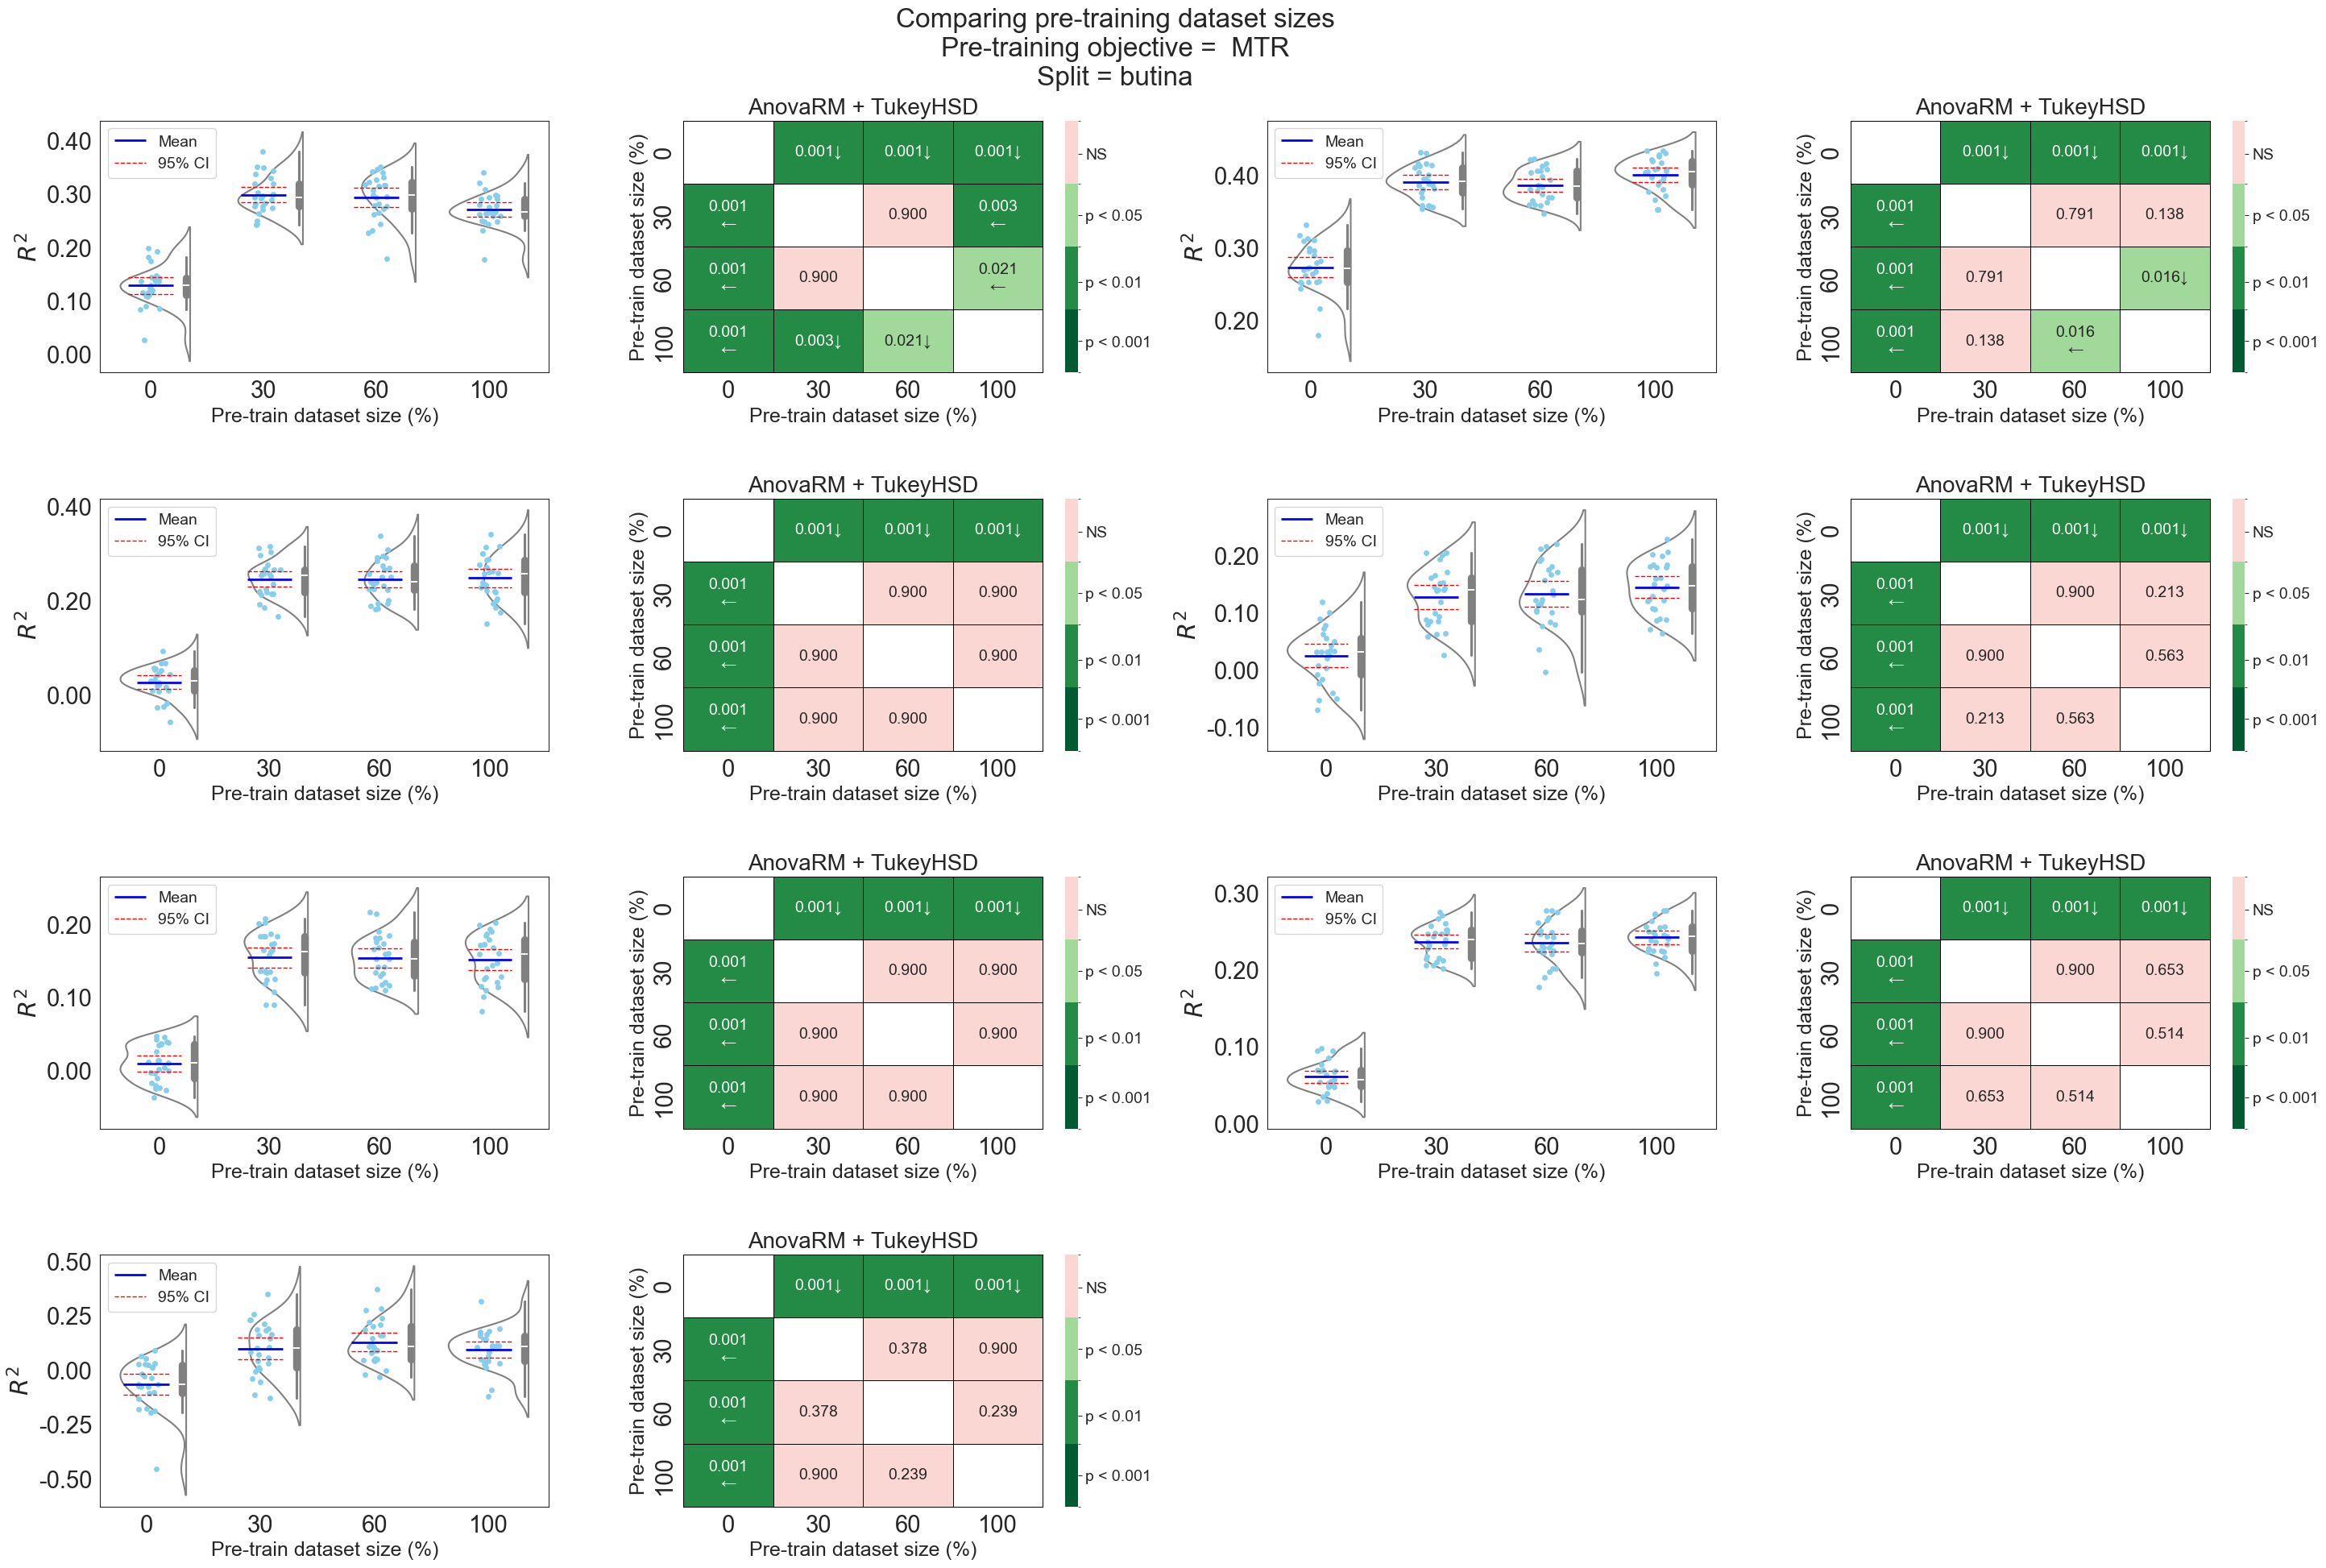

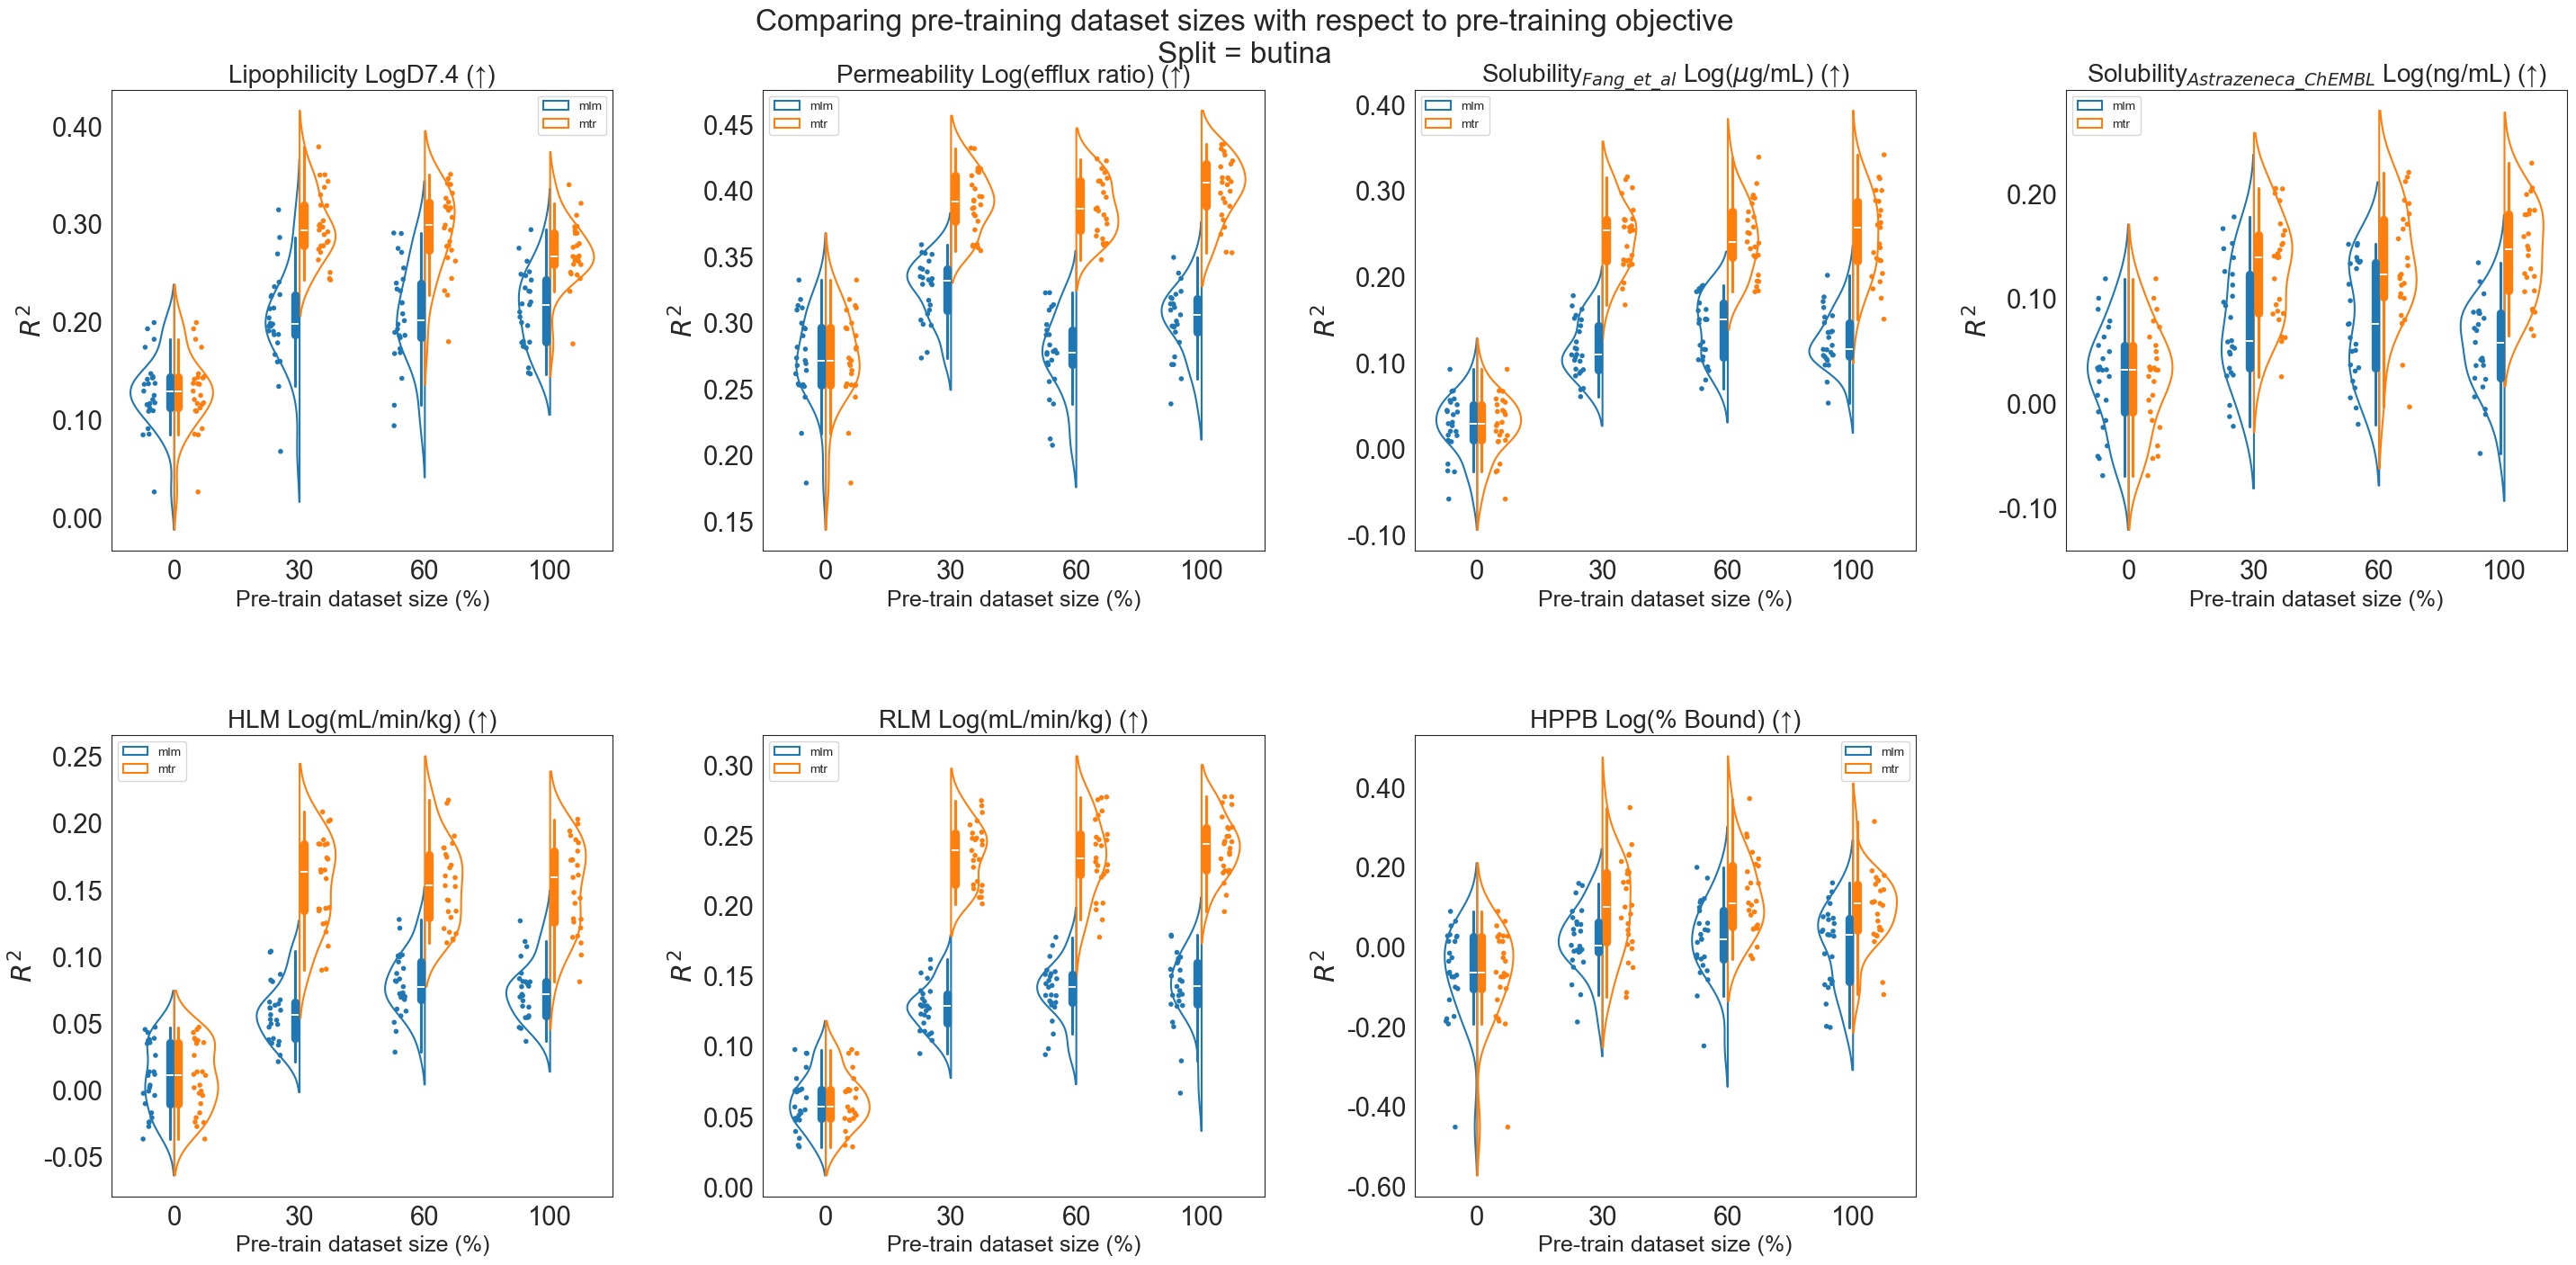

In [61]:
# Close any previous plots
plt.close()

# Base name for saved figure
fig_name = 'scaling'

# Grouping variable for plotting (e.g., x-axis category)
group_col = 'train_size'

# Iterate over different pretraining objectives
for pretrain_objective in ['mlm', 'mtr', 'mlm_vs_mtr']:  
    updated_fig_name = f'{pretrain_objective}_{fig_name}'
    
    # Set up subplots based on the type of objective
    if pretrain_objective == 'mlm_vs_mtr':
        # Special layout for comparison of both objectives
        fig, axes = plt.subplots(2, 4, figsize=(30, 15))
        axes = axes.flatten()
        axes[-1].axis('off')  # Hide the last axis if unused
    else:
        # Standard layout with dynamic number of rows
        import math
        n_datasets = len(datasets)
        n_rows = math.ceil(n_datasets / 2)
        fig, axes = plt.subplots(n_rows, 4, figsize=(30, 5 * n_rows))
    
    # Set spacing and margins for the figure
    wspace = 0.3
    bottom = 0.05
    right = 0.99
    left = 0.08
    top = 0.91
    hspace = 0.5  
    
    # Iterate over each dataset
    for idx, ds in enumerate(datasets):
        title = f'{ds} ({arrow_direction[metric]})'
        
        if pretrain_objective != 'mlm_vs_mtr':
            # Standard plotting logic (non-comparative)
            row_idx = idx // 2
            col_base = (idx % 2) * 2
            ax = axes[row_idx, col_base]

            # Filter the relevant data for this dataset and objective
            objective_df = metrics_by_objective[pretrain_objective]
            ds_df = objective_df[(objective_df['dataset'] == ds) & (objective_df['da'] == 'No DA')]

            # Plot violin (distribution) and strip (points) plots
            sns.violinplot(data=ds_df, x=group_col, y=metric, color='gray', width=0.7, fill=False, ax=ax, split=True)
            sns.stripplot(data=ds_df, x=group_col, y=metric, color='skyblue', jitter=True, size=5, zorder=1, ax=ax)

            # Add confidence intervals and means
            for i, (train_size, group) in enumerate(ds_df.groupby(group_col)):
                confidence = 0.95
                mean, (lower, upper) = ttest_ci(group[metric], confidence)
                label_mean = 'Mean' if i == 0 else None
                label_ci = f'{confidence*100:.0f}% CI' if i == 0 else None
                width = 0.2
                ax.hlines(mean, i - width, i + width, colors='blue', linewidth=2, label=label_mean)
                ax.hlines([lower, upper], i - width, i + width, colors='red', linestyle='dashed', linewidth=1, label=label_ci)
            
            # Run repeated measures ANOVA
            model = AnovaRM(data=ds_df, depvar=metric, subject='fold', within=[group_col]).fit()
            anovaRM_pval = model.anova_table['Pr > F'].iloc[0]
        
            # Plot statistical significance heatmap from TukeyHSD
            ax2 = axes[row_idx, col_base + 1]
            ax2.set_title('AnovaRM + TukeyHSD', fontsize=fontsize-4)
            _, df_means, df_means_diff, significance_matrix = rm_tukey_hsd(ds_df, metric, 'train_size', 'fold')
            plot_sns_heatmap(
                significance_matrix.sort_index().sort_index(axis=1), 
                df_means_diff.sort_index().sort_index(axis=1), 
                ax2, 
                apply_mask=True,
                higher_is_better=False if metric in ['MAE', 'RMSE'] else True
            )

            # Set axis labels and ticks
            ax2.set_xlabel("Pre-train dataset size (%)", fontsize=fontsize-6)
            ax2.set_ylabel("Pre-train dataset size (%)", fontsize=fontsize-6)
            ax2.tick_params(axis='both', which='major', labelsize=fontsize-3)
            ax.legend(fontsize=14)
        else:
            # Plotting logic for comparing both objectives
            ax = axes[idx]
            ax.set_title(title, fontsize=fontsize-4)
            ds_df = predictions_metrics[(predictions_metrics['dataset'] == ds) & (predictions_metrics['da'] == 'No DA')]
            
            # Plot violin and strip plots with hue (different objectives)
            sns.violinplot(data=ds_df, x=group_col, y=metric, width=0.7, fill=False, ax=ax, hue='pretrain_objective', split=True)
            sns.stripplot(data=ds_df, x=group_col, y=metric, jitter=True, dodge=True, size=4, zorder=1, ax=ax, hue='pretrain_objective')

            # Custom legend (only first two entries)
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles[0:2], labels[0:2])
            
            # Adjust margins and spacing
            hspace = 0.4
            wspace = 0.3
            top = 0.92
            bottom = 0.1
            right = 0.99
            left = 0.08
    
        # Set common axis labels and tick formatting
        ax.set_xlabel('Pre-train dataset size (%)', fontsize=fontsize-6)
        ax.set_ylabel(f'{metric_styling[metric]}', fontsize=fontsize-2)
        ax.tick_params(axis='both', which='major', labelsize=fontsize-3)
        ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))
        
    # Add a main title and hide unused axes if necessary
    if pretrain_objective != 'mlm_vs_mtr':
        suptitle = f'Comparing pre-training dataset sizes\nPre-training objective =  {pretrain_objective.upper()}'
        total_axes = axes.shape[0] * axes.shape[1]
        used_axes = len(datasets) * 2  # Two plots per dataset
        for ax_idx in range(used_axes, total_axes):
            row = ax_idx // 4
            col = ax_idx % 4
            axes[row, col].axis('off')
    else:
        suptitle = 'Comparing pre-training dataset sizes with respect to pre-training objective'

    # Finalize and save the figure
    plt.suptitle(f'{suptitle}\nSplit = {split_file}', fontsize=fontsize)
    plt.subplots_adjust(hspace=hspace, wspace=wspace, top=top, bottom=bottom, right=right, left=left)
    plt.savefig(os.path.join(out_dir, f'{updated_fig_name}.{figure_extension}'))
    plt.show()


## Domain adaptation (DA)
We show the distribution and significance using paired ttest for the model with no DA vs. any other model with DA
* The DA experiments were not fully performed for the models pre-trained with the MTR objectives as it was not part of our research questions. 

In [62]:
pretrain_ds_size = 30

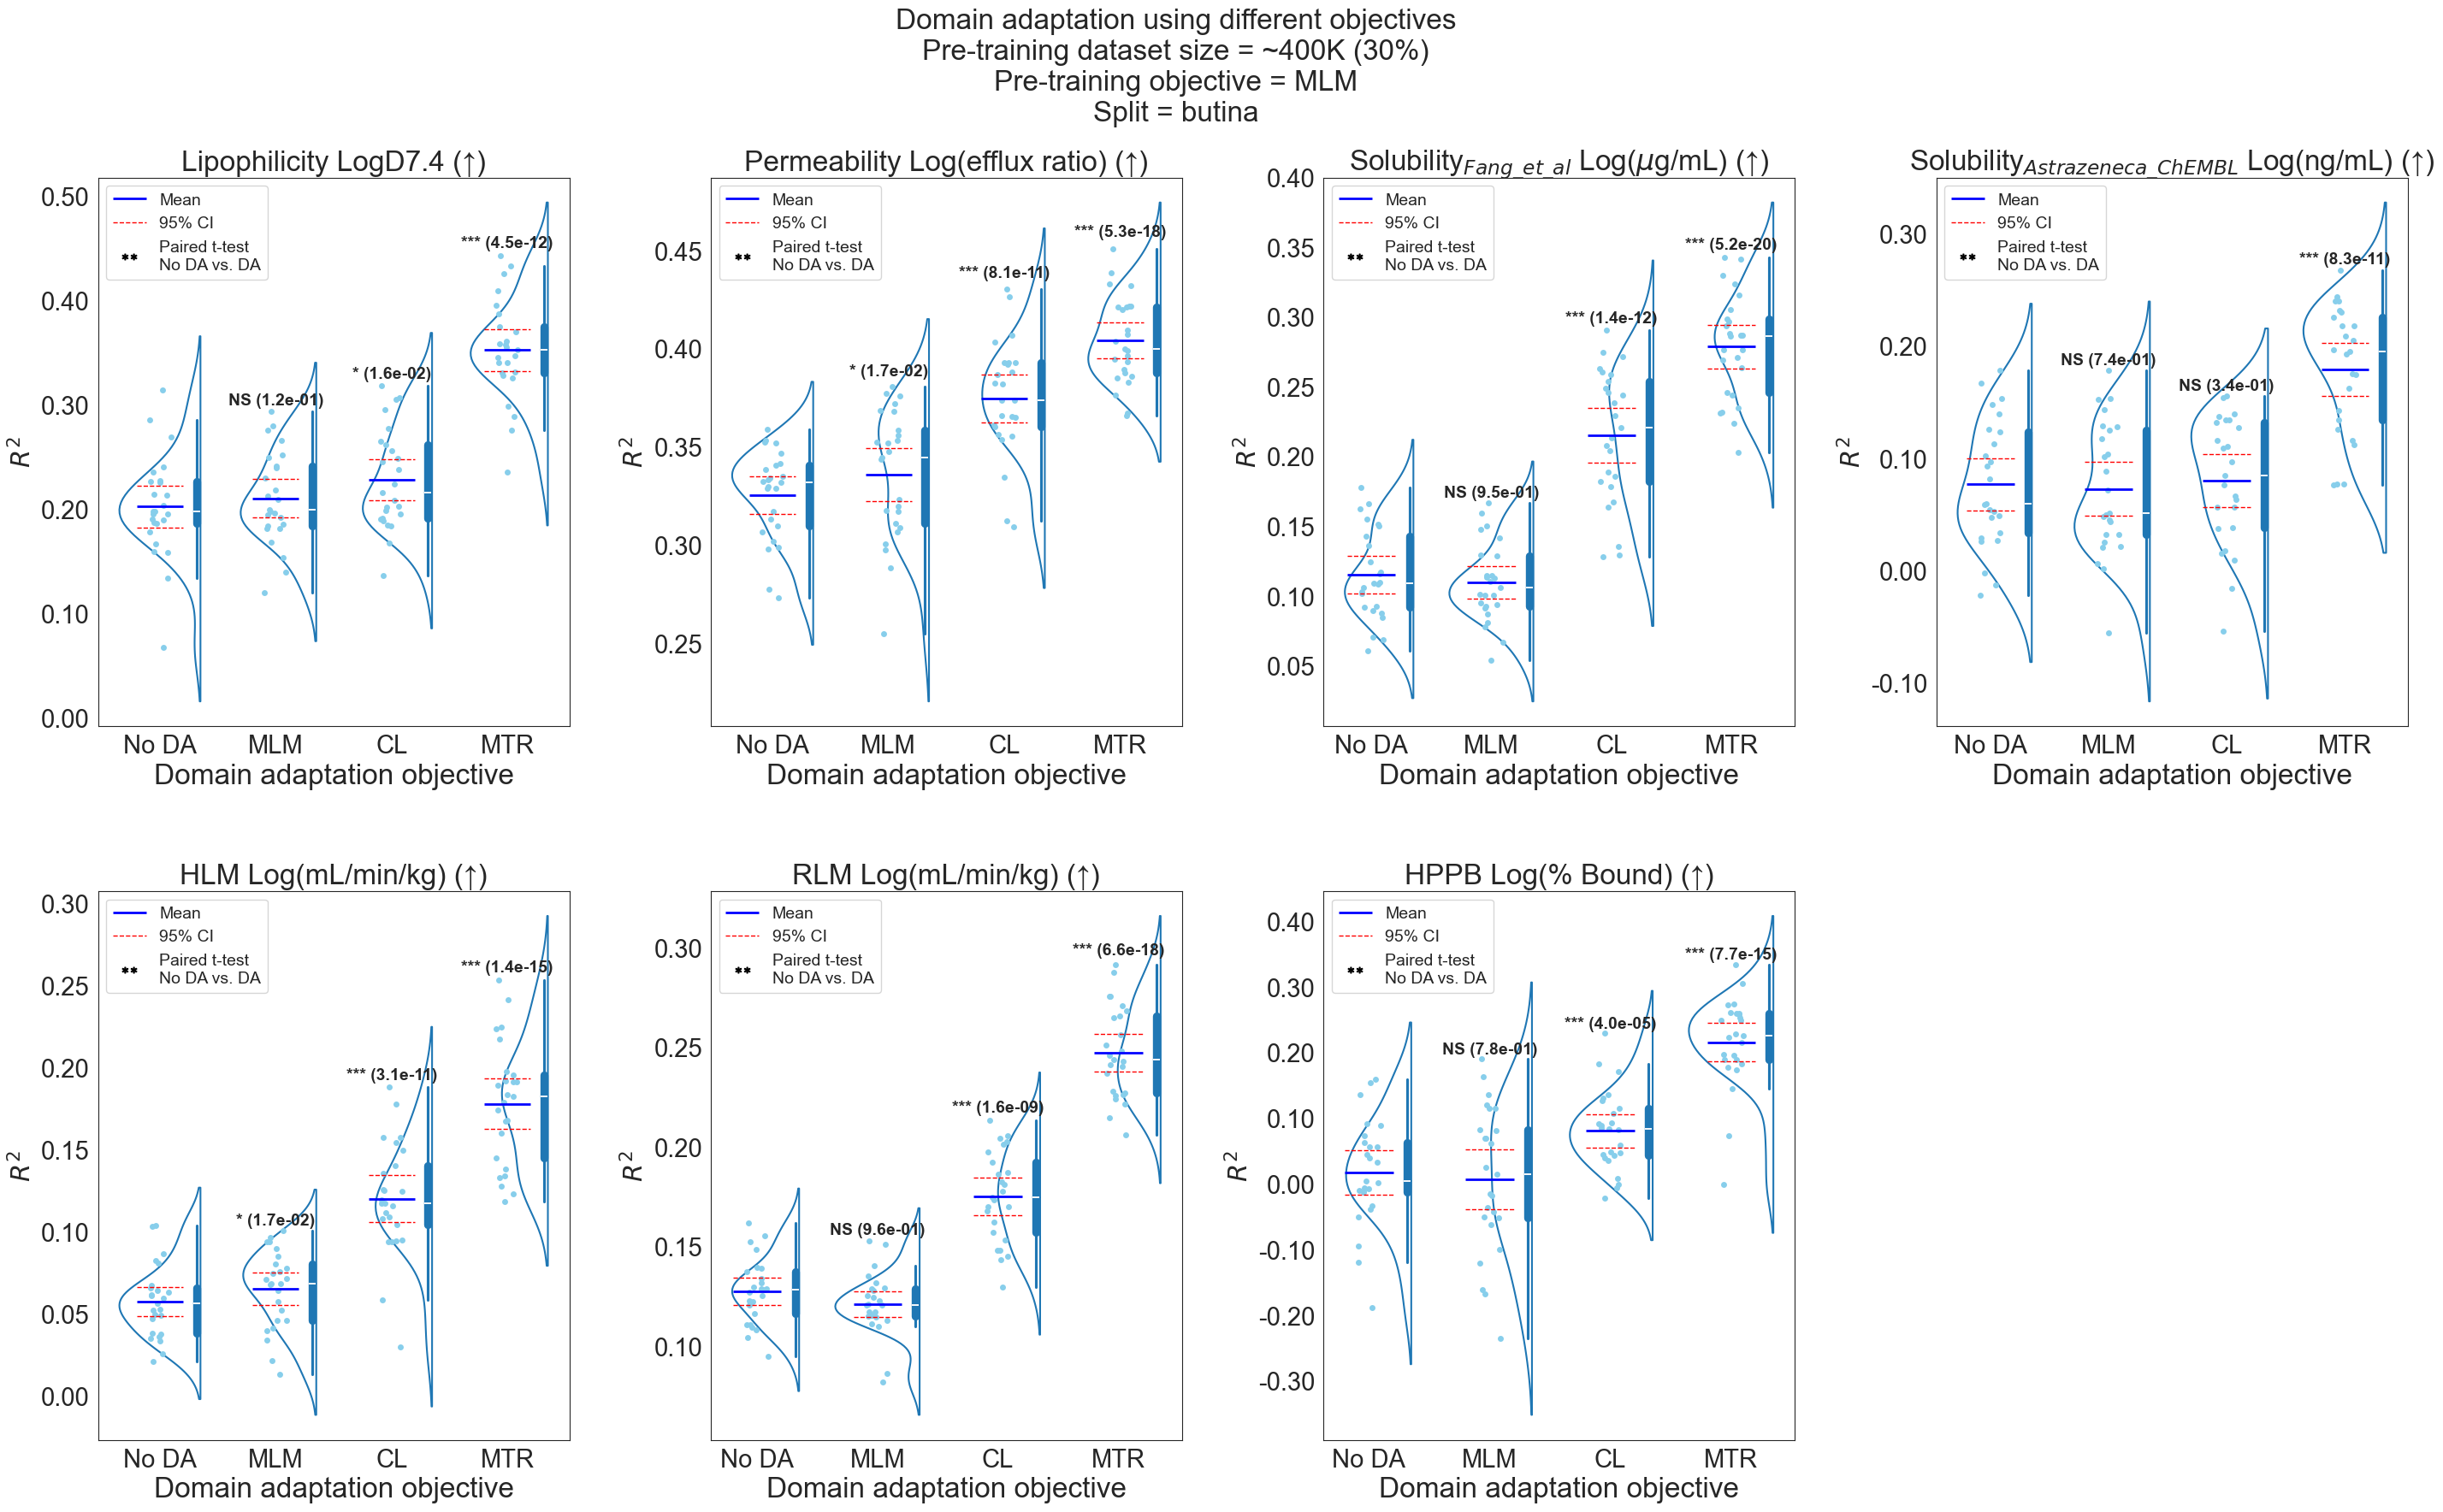

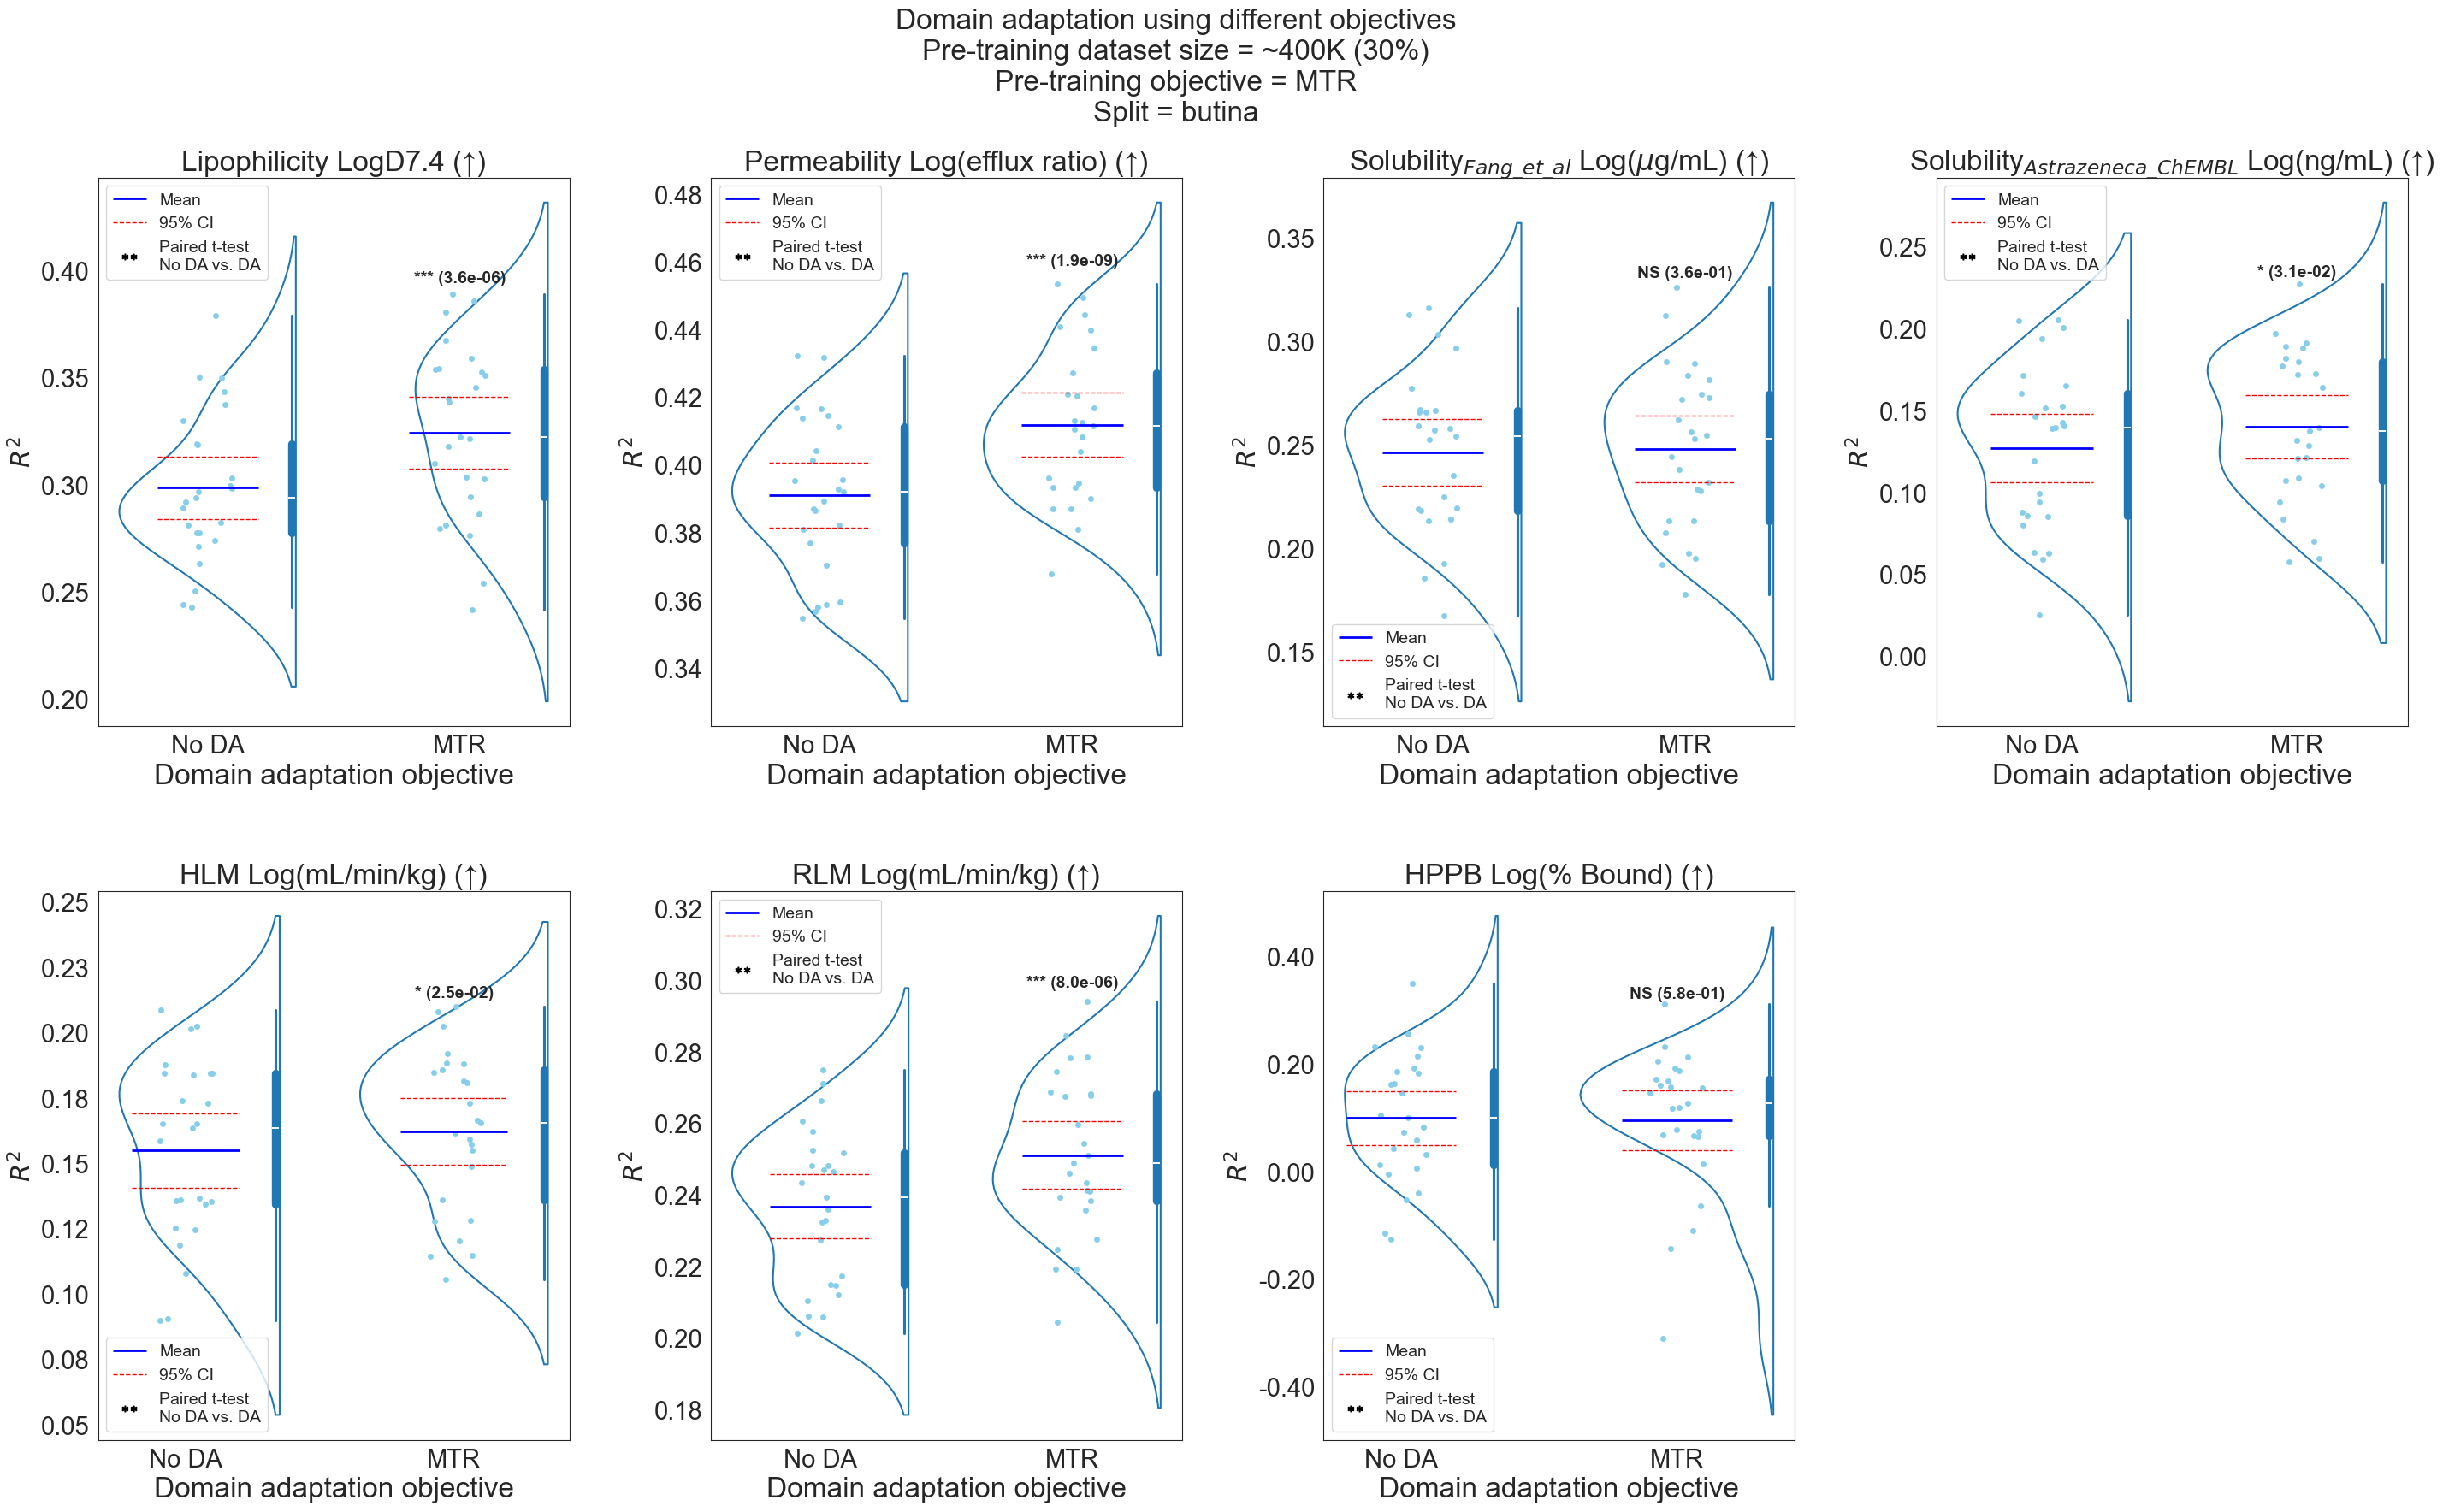

In [63]:
plt.close()

datasets_info = {}
for pretrain_objective, da_models in {'mlm': ['MLM', 'CL', 'MTR'], 'mtr': ['MTR']}.items():
    datasets_info[pretrain_objective] = {}
    # Create a subplot grid with one subplot for each dataset
    fig, axes = make_figure(len(datasets), 4, width=30, height_ratio=fig_height_ratio)
    fig_name = f'{pretrain_objective}_{pretrain_ds_size}_da'
    axes[-1].axis('off')
    
    group_col = 'da'
    for idx, ds in enumerate(datasets):
        datasets_info[pretrain_objective][ds] = {}
        ax = axes[idx]
        ax.set_title(f'{ds} ({arrow_direction[metric]})', fontsize=fontsize)
        ax.set_xlabel(f'Domain adaptation objective', fontsize=fontsize)
        ax.set_ylabel(f'{metric_styling[metric]}', fontsize=fontsize-2)
        ax.tick_params(axis='both', which='major', labelsize=fontsize-3)
        ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))
            
        objective_df = metrics_by_objective[pretrain_objective]
        ds_df = objective_df[(objective_df['dataset'] == ds) & (objective_df["train_size"] == pretrain_ds_size)].copy()   
        ds_df['da'] = ds_df['da'].cat.remove_unused_categories()
        sns.violinplot(data=ds_df, x=group_col, y=metric, width=0.7, fill=False, ax=ax, split=True)
                            
        # Overlay individual data points
        sns.stripplot(data=ds_df, x=group_col, y=metric, color='skyblue', jitter=True, size=5, zorder=1, ax=ax)
     
        for i, (da_name, group) in enumerate(ds_df.groupby(group_col, observed=False)):
            confidence = 0.95
            mean, (lower, upper) = ttest_ci(group[metric], confidence)
            label_mean = 'Mean' if i == 0 else None
            label_ci = f'{confidence*100:.0f}% CI' if i == 0 else None    
            
            datasets_info[pretrain_objective][ds][da_name] = mean
            
            # Adjust width of horizontal lines to just span one violin
            width = 0.2  # Half-width of the horizontal line
            ax.hlines(mean, i - width, i + width, colors='blue', linewidth=2, label=label_mean)
            ax.hlines([lower, upper], i - width, i + width, colors='red', linestyle='dashed', linewidth=1, label= label_ci)
            
    
        no_da_vs_da = {}   
        for da_model in da_models:
            # Subset to the two DA conditions being compared
            df_da_subset = ds_df[ds_df['da'].isin(['No DA', da_model])]
        
            # Pivot to align values by SMILES for pairing
            df_pivot = df_da_subset.pivot(index='fold', columns="da", values=metric)
        
            # Drop rows with missing values (ensure valid pairing)
            df_pivot = df_pivot.dropna(subset=['No DA', da_model])
        
            # Extract paired metric values
            group_no_da = df_pivot['No DA'].values
            group_da = df_pivot[da_model].values
        
            # Perform paired t-test (no correction needed)
            stat, pval = ttest_rel(group_no_da, group_da, alternative='greater' if metric in ['MAE', 'RMSE'] else 'less')
        
            # Store raw p-value
            no_da_vs_da[da_model] = pval
    
        # Get tick labels and their actual x-positions
        xtick_labels = [tick.get_text() for tick in ax.get_xticklabels()]
        xtick_positions = ax.get_xticks()
        x_lut = dict(zip(xtick_labels, xtick_positions))
    
        # Annotate p-values
        for da_model in da_models:
            pval = no_da_vs_da[da_model]
    
            # Significance stars
            if pval <= 0.001:
                stars = '***'
            elif pval <= 0.01:
                stars = '**'
            elif pval <= 0.05:
                stars = '*'
            else:
                stars = 'NS'
    
            if stars:
                label = f'{stars} ({pval:.1e})'
    
                # Get x-position for this DA model from tick label mapping
                x_pos = x_lut.get(da_model, None)
                if x_pos is None:
                    continue  # skip if the model isn't on the axis (just in case)
    
                # Y-position: slightly above the current y max
                y_max = ds_df[ds_df['da'] == da_model][metric].max()
                y_offset = 0.01 * abs(y_max)
                y_pos = y_max + y_offset
    
                ax.text(x_pos, y_pos, label, ha='center', va='bottom', fontsize=14, fontweight='bold')
    
        # Create a custom asterisk marker for the legend
        asterisk_handle = Line2D(
            [0], [0],
            marker='$**$',
            color='black',
            linestyle='None',
            markersize=12,
            label='Paired t-test\nNo DA vs. DA'
        )
        
        # Add to the legend
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles + [asterisk_handle], labels + [asterisk_handle.get_label()], fontsize=14)
            
        #ax.legend()
    
    wspace=0.3
    hspace=0.3
    top = 0.87 
    bottom = 0.05
    right = 0.98
    left = 0.08
    plt.subplots_adjust(top=top, bottom=bottom, right=right, left=left, wspace=wspace, hspace=hspace)      
    
    plt.suptitle(f'Domain adaptation using different objectives\nPre-training dataset size = ~400K (30%)\nPre-training objective = {pretrain_objective.upper()}\nSplit = {split_file}', fontsize=fontsize)
    
    plt.savefig(os.path.join(out_dir, f'{fig_name}.{figure_extension}'))

## How to efficiently use the MTR objective
We already showed that the MTR objective is better than the MLM objective when used during pre-training. We also showed that it improves the performance significantly when used for domain adaptation. So, the question arising is "**should we use MTR for pre-training, domain adaptation, and/or both?**"
* MTR is an expensive objective to calculate for millions of molecules and to optimize by the model. So, using it during pre-training comes with a cost. Is the cost worth it?

The below analysis tries to answer this question by comparing 4 models that span no use of MTR at all to using MTR during both pre-training and domain adaptation (the 30% pre-training dataset size setup is fixed for all models):
1. pre-training with MLM and no domain adaptation `MLM_No DA`
2. pre-training with MLM and domain adaptation with MTR `MLM_MTR`
3. pre-training with MTR and no domain adaptation `MTR_No DA`
4. pre-training with MTR and domain adaptation with MTR `MTR_MTR`

The most efficient model that uses MTR is the `MLM_MTR` because the model is pre-trained with the very simple MLM objective, and MTR is used for domain adaptation only, which is performed for a few thousand molecules. 


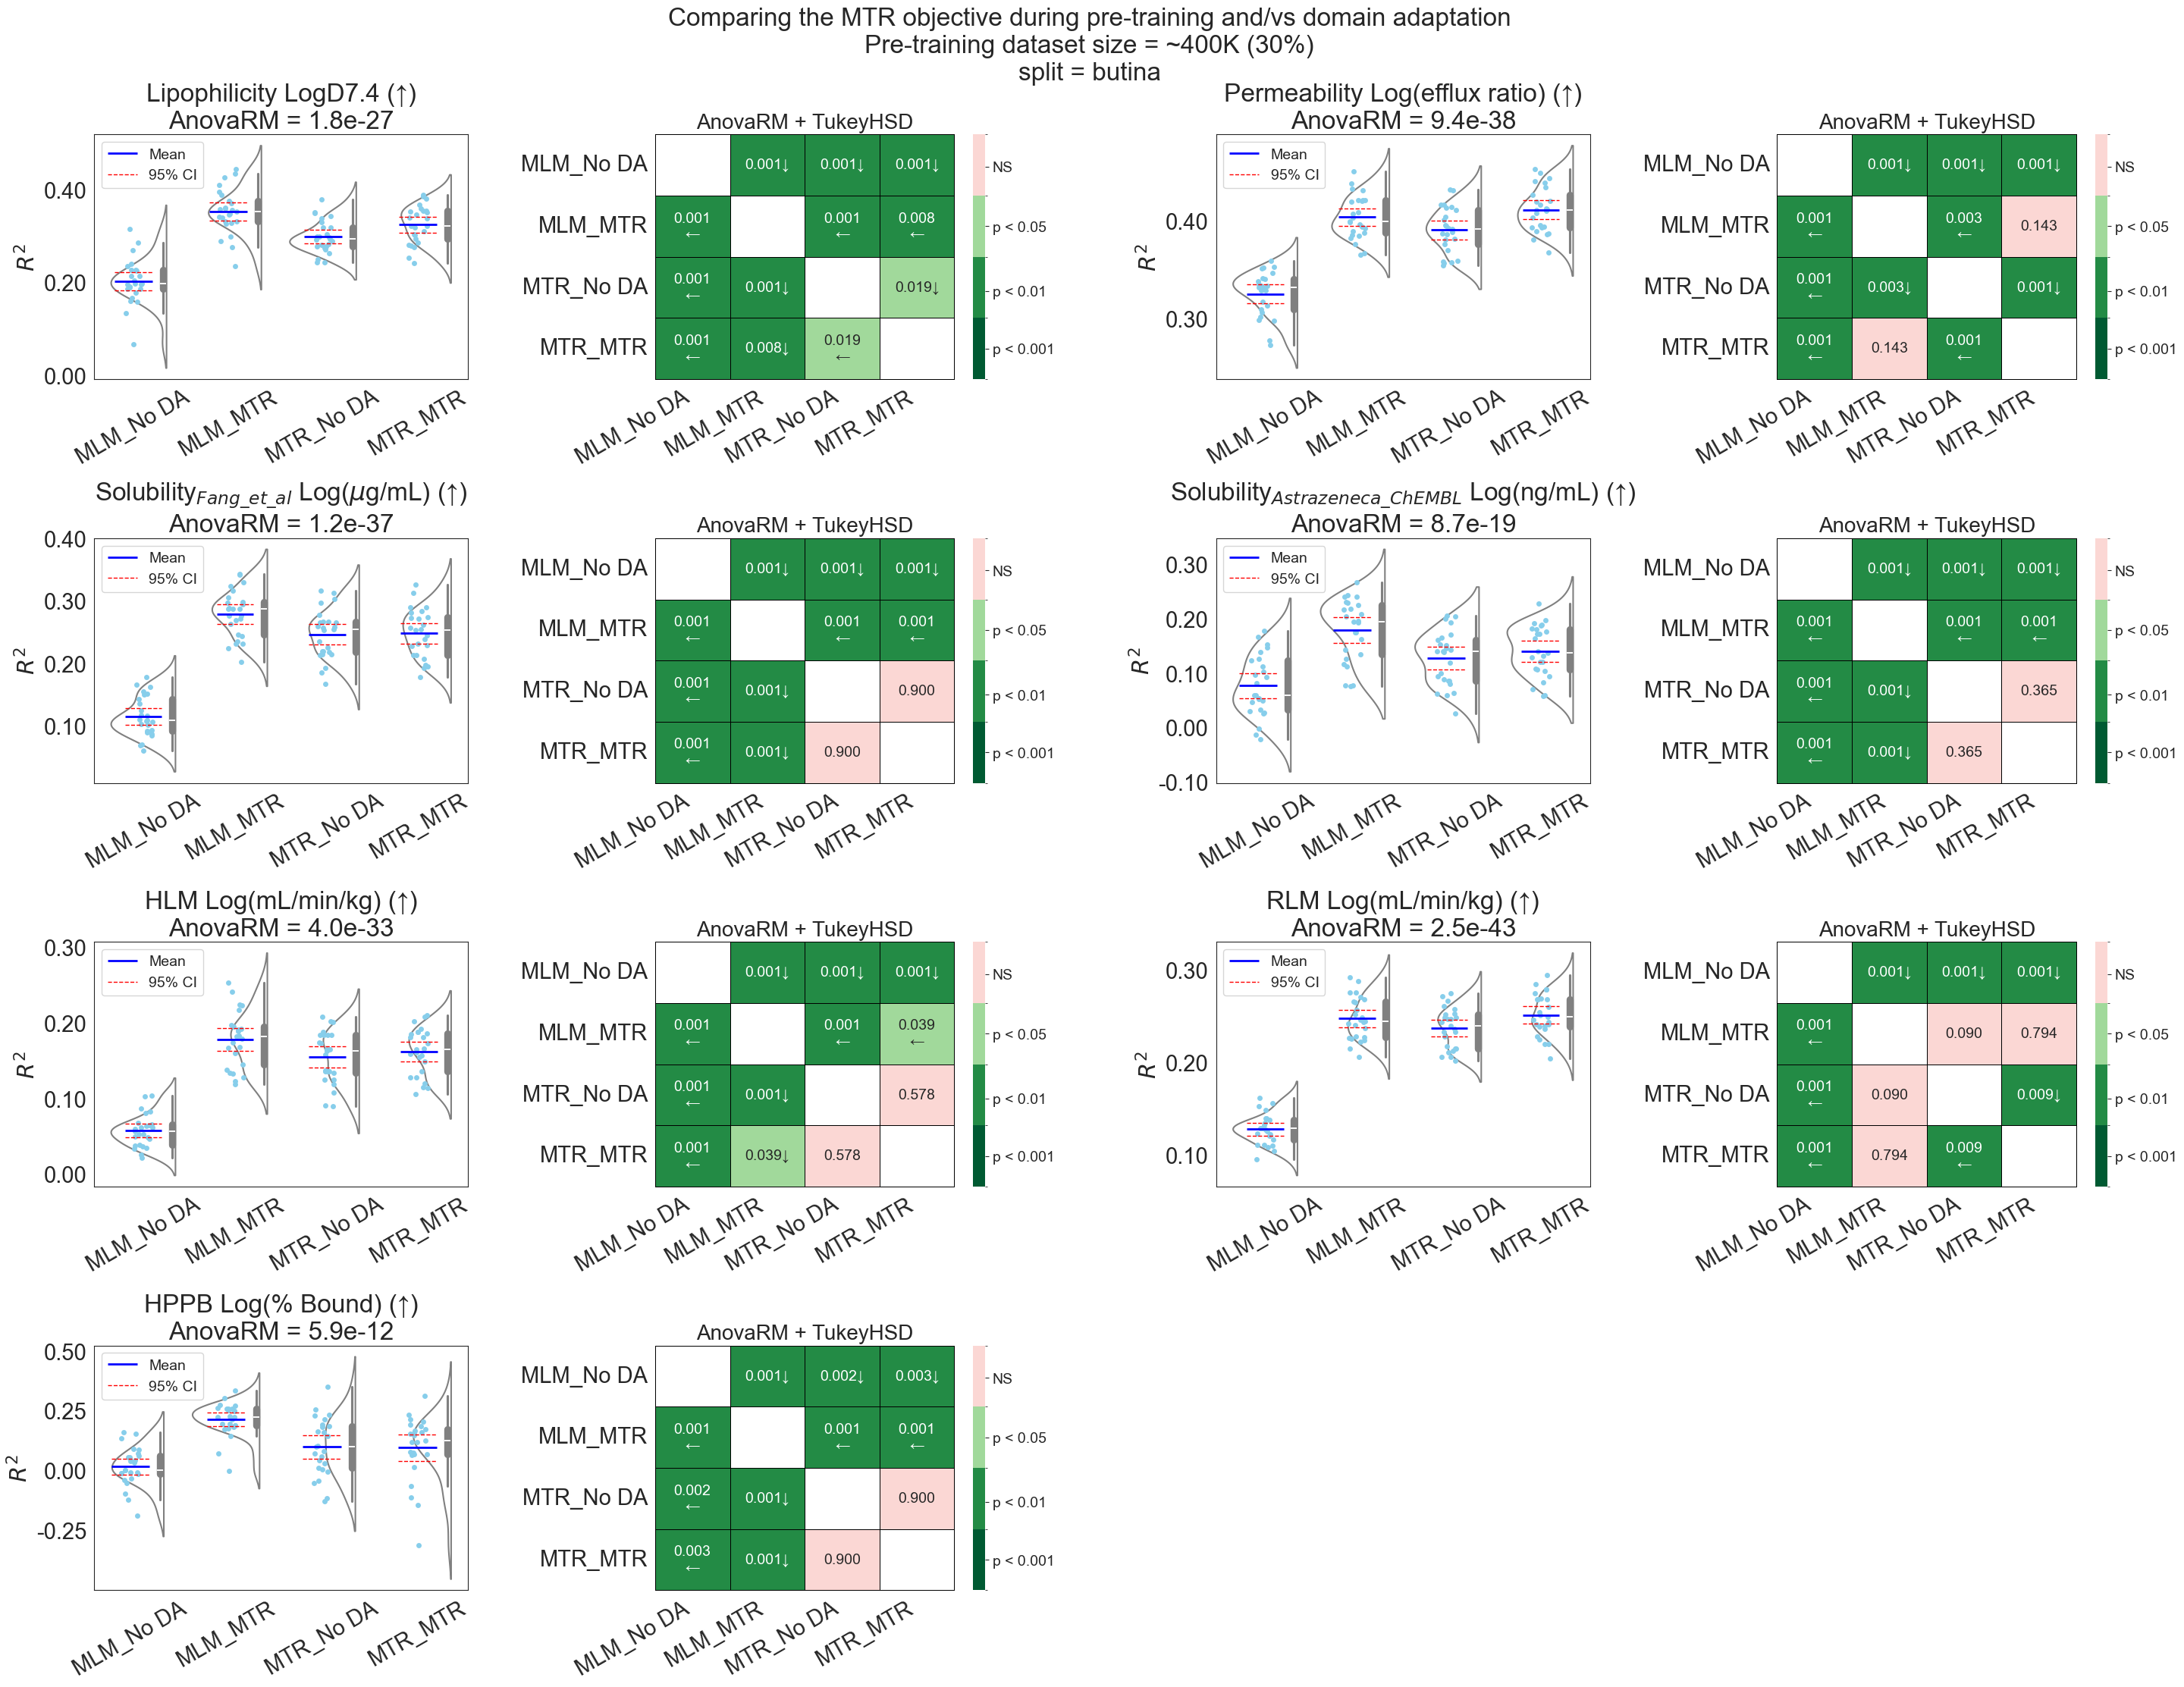

In [64]:
# Filter for train_size = 30 and DA in ['No DA', 'MTR']
filtered = predictions_metrics[
    (predictions_metrics['train_size'] == pretrain_ds_size) &
    (predictions_metrics['da'].isin(['No DA', 'MTR'])) &
    (predictions_metrics['pretrain_objective'].isin(['mlm', 'mtr']))
].copy()

# Create new 'da' label combining pretrain_objective and da
filtered['da'] = filtered['pretrain_objective'].str.upper() + '_' + filtered['da'].astype(str)

# Reorder categories for plotting
sort_order = ['MLM_No DA', 'MLM_MTR', 'MTR_No DA', 'MTR_MTR']
filtered['da'] = pd.Categorical(filtered['da'], categories=sort_order, ordered=True)
filtered = filtered.sort_values(by='da')

# Final cleaned DataFrame
mlm_vs_mtr_vs_da_30 = filtered

n_datasets = len(datasets)
n_rows = math.ceil(n_datasets / 2)
fig, axes = plt.subplots(n_rows, 4, figsize=(35, 6 * n_rows))  # 4 columns: 2 plots per dataset

for idx, ds in enumerate(datasets):
    row_idx = idx // 2
    col_base = (idx % 2) * 2

    ax = axes[row_idx, col_base]
    ax.set_ylabel(f'{metric_styling[metric]}', fontsize=fontsize-2)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-3)
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))
    
    ds_df = mlm_vs_mtr_vs_da_30[mlm_vs_mtr_vs_da_30['dataset'] == ds]
    
    model = AnovaRM(data=ds_df, depvar=metric, subject='fold', within=['da']).fit()
    anovaRM_pval = model.anova_table['Pr > F'].iloc[0]
    ax.set_title(f'{ds} ({arrow_direction[metric]})\nAnovaRM = {anovaRM_pval:.1e}', fontsize=fontsize)
    
    sns.violinplot(data=ds_df, x='da', y=metric, color='gray', width=0.7, fill=False, ax=ax, split=True)
    sns.stripplot(data=ds_df, x='da', y=metric, color='skyblue', jitter=True, size=5, zorder=1, ax=ax)
  
    for i, (_, group) in enumerate(ds_df.groupby('da', observed=False)):
        confidence = 0.95
        mean, (lower, upper) = ttest_ci(group[metric], confidence)
        label_mean = 'Mean' if i == 0 else None
        label_ci = f'{confidence*100:.0f}% CI' if i == 0 else None  
        
        width = 0.2
        ax.hlines(mean, i - width, i + width, colors='blue', linewidth=2, label=label_mean)
        ax.hlines([lower, upper], i - width, i + width, colors='red', linestyle='dashed', linewidth=1, label=label_ci)
    
    for label in ax.get_xticklabels():
        label.set_rotation(30)  
        label.set_ha('center')     
    ax.legend(fontsize=14)
    ax.set_xlabel('')
    
    ax2 = axes[row_idx, col_base + 1]
    ax2.set_title('AnovaRM + TukeyHSD', fontsize=fontsize-4)
            
    _, df_means, df_means_diff, significance_matrix = rm_tukey_hsd(ds_df, metric, 'da', 'fold')
    plot_sns_heatmap(significance_matrix.sort_index().sort_index(axis=1), 
                     df_means_diff.sort_index().sort_index(axis=1), 
                     ax2, 
                     apply_mask=True,
                     higher_is_better=False if metric in ['MAE', 'RMSE'] else True)
    ax2.tick_params(axis='both', which='major', labelsize=fontsize-3)
    ax2.set_xlabel('')
    ax2.set_ylabel('')
    
    for label in ax2.get_xticklabels():
        label.set_rotation(30)  
        label.set_ha('right') 
    for label in ax2.get_yticklabels():
        label.set_rotation(0)

# Turn off unused axes
total_axes = axes.shape[0] * axes.shape[1]
used_axes = len(datasets) * 2
for ax_idx in range(used_axes, total_axes):
    row = ax_idx // 4
    col = ax_idx % 4
    axes[row, col].axis('off')

plt.subplots_adjust(top=0.91, hspace=0.65, wspace=0.5)
plt.suptitle(
    f'Comparing the MTR objective during pre-training and/vs domain adaptation\n'
    f'Pre-training dataset size = ~400K (30%)\nsplit = {split_file}', 
    fontsize=fontsize
)
plt.savefig(os.path.join(out_dir, f'mtr_pretrain_vs_da_{pretrain_ds_size}.{figure_extension}'), bbox_inches='tight')
plt.show()


# Benchmarking

## Loading comparison results
Here, we load the same files as loaded for our experiments, the raw predictions by the models and the evaluated predictions. The models are:
1. RF + MolBERT embeddings
2. RF + MolFormer embeddings
3. RF + RDKit descriptors
4. RF + Morgan fingerprints (FPs)

In [65]:
comparisons_metrics_df = pd.DataFrame()
for data_source in  ['astrazeneca', 'adme']:
    # Loading the evaluated file. Here, we have the different metrics for each fold of the 5*5-folds 
    experiments_metrics = f'{experiment_dir}/{data_source}_{split_file}_comparison_metrics_df.csv'
    experiments_metrics_df = pd.read_csv(experiments_metrics, index_col=0)
    if data_source == 'astrazeneca':
        experiments_metrics_df['dataset'] = experiments_metrics_df['dataset'].replace('Solubility Log(ng/mL)', 'Solubility$_{Astrazeneca\_ChEMBL}$ Log(ng/mL)')
    else:
        experiments_metrics_df['dataset'] = experiments_metrics_df['dataset'].replace('Solubility Log(ug/mL)', 'Solubility$_{Fang\_et\_al}$ Log($\mu$g/mL)')
    comparisons_metrics_df = pd.concat([comparisons_metrics_df, experiments_metrics_df])

comparisons_metrics_df = comparisons_metrics_df[kept_cols]
comparisons_metrics_df['model'] = comparisons_metrics_df['pretrain_objective']
comparisons_metrics_df['model'] = comparisons_metrics_df['model'].replace({
    'physchem': 'RDKit descriptors',
    'fingerprint': 'Morgan FPs',
    'molbert': 'MolBERT',
    'molformer': 'MolFormer'
})

## Comparing our most efficient model to literature
Our model is extremely efficient compared to the other two transformer models
* Ours vs MolBERT: 
    * pre-training molecules: 400K vs 1.3M
    * Pre-training objectives: MLM vs MLM + MTR + SMILES-EQ
* Ours vs MolFormer:
    * pre-training molecules: 400K vs 100M
    * Pre-training objectives: MLM vs MLM

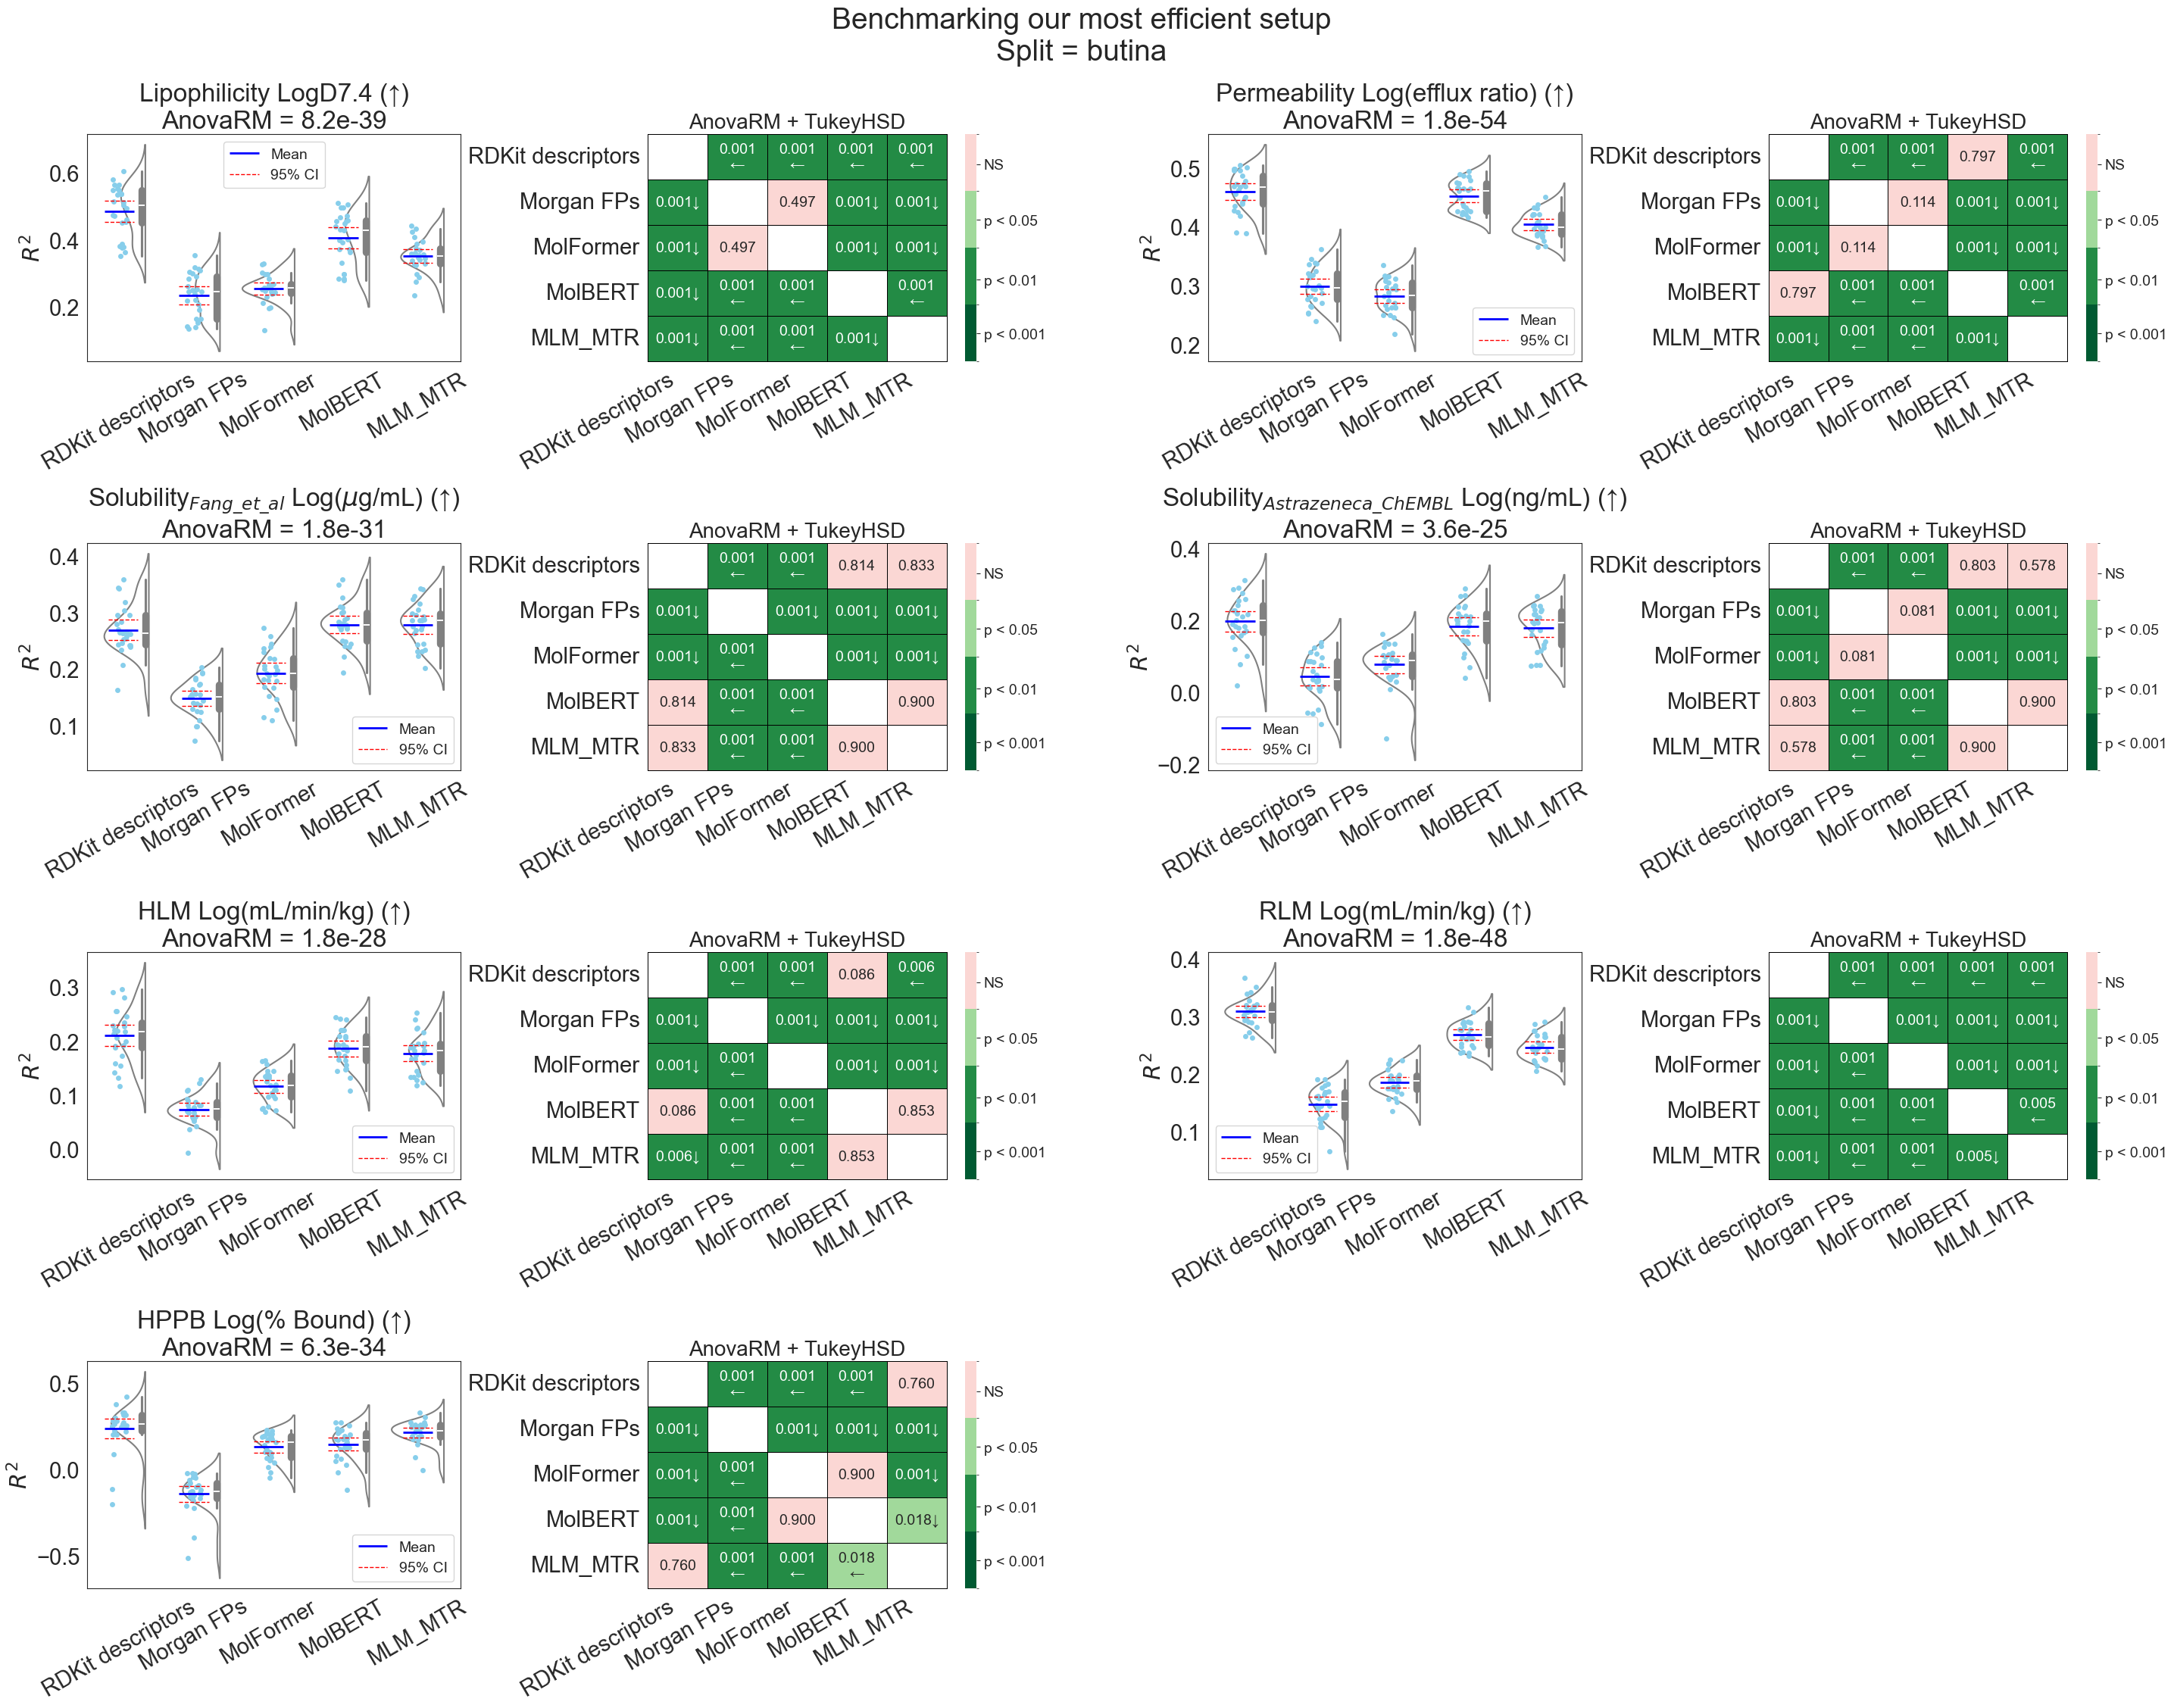

In [66]:
plt.close()

pretrain_objective = 'mlm'
pretrain_objective_df = metrics_by_objective[pretrain_objective]
best_da = 'MTR'
pretrain_da = pretrain_objective_df[
    (pretrain_objective_df['da'] == best_da) & 
    (pretrain_objective_df['train_size'] == pretrain_ds_size)
].copy()
pretrain_da.loc[:, 'model'] = pretrain_objective.upper() + '_' + pretrain_da['da'].astype(str) 

literature_plus_ours = pd.concat([comparisons_metrics_df, pretrain_da]).drop_duplicates()
model_order = ['RDKit descriptors', 'Morgan FPs', 'MolFormer', 'MolBERT', 'MLM_MTR']
literature_plus_ours['model'] = pd.Categorical(
    literature_plus_ours['model'],
    categories=model_order,
    ordered=True
)

# Optional: exclude models
# literature_plus_ours = literature_plus_ours[literature_plus_ours['model'] != 'Morgan FPs']
# literature_plus_ours = literature_plus_ours[literature_plus_ours['model'] != 'PhysChem']

import math
n_datasets = len(datasets)
n_rows = math.ceil(n_datasets / 2)
fig, axes = plt.subplots(n_rows, 4, figsize=(35, 6 * n_rows))  # 2 datasets per row (4 subplots)

benchmark_ds_info = {}
for idx, ds in enumerate(datasets):
    benchmark_ds_info[ds] = {}
    row_idx = idx // 2
    col_base = (idx % 2) * 2

    ax = axes[row_idx, col_base]
    ax.set_ylabel(f'{metric_styling[metric]}', fontsize=fontsize-2)
    ax.tick_params(axis='both', which='major', labelsize=fontsize-3)

    ds_df = literature_plus_ours[literature_plus_ours['dataset'] == ds].copy()
    
    model = AnovaRM(data=ds_df, depvar=metric, subject='fold', within=['model']).fit()
    anovaRM_pval = model.anova_table['Pr > F'].iloc[0]
    ax.set_title(f'{ds} ({arrow_direction[metric]})\nAnovaRM = {anovaRM_pval:.1e}', fontsize=fontsize)
    
    sns.violinplot(data=ds_df, x='model', y=metric, color='gray', width=0.7, fill=False, ax=ax, split=True)
    sns.stripplot(data=ds_df, x='model', y=metric, color='skyblue', jitter=True, size=5, zorder=1, ax=ax)

    xtick_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    xtick_positions = ax.get_xticks()
    x_pos_map = dict(zip(xtick_labels, xtick_positions))

    for i, (model_name, group) in enumerate(ds_df.groupby('model', observed=False)):
        x = x_pos_map[model_name]
        confidence = 0.95
        mean, (lower, upper) = ttest_ci(group[metric], confidence)
        benchmark_ds_info[ds][model_name] = mean

        label_mean = 'Mean' if i == 0 else None
        label_ci = f'{confidence*100:.0f}% CI' if i == 0 else None  
        
        width = 0.2
        ax.hlines(mean, x - width, x + width, colors='blue', linewidth=2, label=label_mean)
        ax.hlines([lower, upper], x - width, x + width, colors='red', linestyle='dashed', linewidth=1, label=label_ci)

    ax.legend(fontsize=14)

    for label in ax.get_xticklabels():
        label.set_rotation(30)  
        label.set_ha('center') 
    ax.set_xlabel('')

    ax2 = axes[row_idx, col_base + 1]
    ax2.set_title('AnovaRM + TukeyHSD', fontsize=fontsize-4)

    _, df_means, df_means_diff, significance_matrix = rm_tukey_hsd(ds_df, metric, 'model', 'fold')
    plot_sns_heatmap(significance_matrix.sort_index().sort_index(axis=1), 
                     df_means_diff.sort_index().sort_index(axis=1), 
                     ax2, 
                     apply_mask=True,
                     higher_is_better=False if metric in ['MAE', 'RMSE'] else True)
    ax2.tick_params(axis='both', which='major', labelsize=fontsize-3)
    ax2.set_xlabel('')
    ax2.set_ylabel('')

    for label in ax2.get_xticklabels():
        label.set_rotation(30)  
        label.set_ha('right') 
    for label in ax2.get_yticklabels():
        label.set_rotation(0)

# Turn off unused axes if any
total_axes = axes.shape[0] * axes.shape[1]
used_axes = len(datasets) * 2
for ax_idx in range(used_axes, total_axes):
    row = ax_idx // 4
    col = ax_idx % 4
    axes[row, col].axis('off')

plt.subplots_adjust(top=0.91, hspace=0.8, wspace=0.5)
plt.suptitle(f'Benchmarking our most efficient setup\nSplit = {split_file}', fontsize=fontsize+4)
plt.savefig(os.path.join(out_dir, f'{pretrain_objective}_{pretrain_ds_size}_{best_da}_benchmark.{figure_extension}'), bbox_inches='tight')
plt.show()